# Import

In [1]:
%load_ext autoreload
%autoreload 2

# Import required packages
import torch
import numpy as np
import normflows as nf
from torch.utils.data import TensorDataset, DataLoader, random_split

from matplotlib import pyplot as plt

from tqdm import tqdm

import joblib
import sklearn
import datetime

import sys
sys.path.append('../src')
import ice

from scipy.io import loadmat
torch.multiprocessing.set_start_method('spawn', force=True)

# Preprocessing

## Standardize

Text(0.5, 1.0, 'radar flight path, NGrIS')

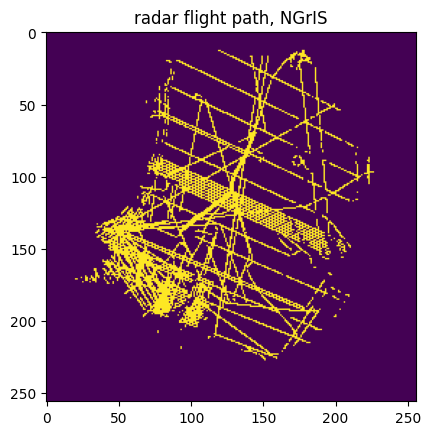

In [2]:
radar_mask = loadmat("../data/NGrIS/ensemble_data_pixelated/radar_mask.mat")['radar_mask']
radar_mask = (radar_mask == 1)

plt.imshow(radar_mask)
plt.title('radar flight path, NGrIS')

In [3]:
from shapely.geometry import Point
from shapely.geometry.polygon import Polygon

x = loadmat('../data/NGrIS/ensemble_data_pixelated/x_grid.mat')['grid_x_center']
y = loadmat('../data/NGrIS/ensemble_data_pixelated/y_grid.mat')['grid_y_center']
coor_xy = np.hstack((x.flatten()[:, np.newaxis], y.flatten()[:, np.newaxis]))

NW_boundary = loadmat('../data/NGrIS/boundary/NW_boundary_ordered.mat')['NW_boundary_ordered']
NO_boundary = loadmat('../data/NGrIS/boundary/NO_boundary_ordered.mat')['NO_boundary_ordered']
NE_boundary = loadmat('../data/NGrIS/boundary/NE_boundary_ordered.mat')['NE_boundary_ordered']

NW_polygon = Polygon(NW_boundary[:, 1:])
NO_polygon = Polygon(NO_boundary[:, 1:])
NE_polygon = Polygon(NE_boundary[:, 1:])

in_NW = np.full(len(coor_xy), np.nan)
in_NO = np.full(len(coor_xy), np.nan)
in_NE = np.full(len(coor_xy), np.nan)

for i in range(len(coor_xy)):
    pt = Point(coor_xy[i, :])
    in_NW[i] = NW_polygon.contains(pt)
    in_NO[i] = NO_polygon.contains(pt)
    in_NE[i] = NE_polygon.contains(pt)

in_NW = in_NW.reshape((256, 256))
in_NW = (in_NW == 1)

in_NO = in_NO.reshape((256, 256))
in_NO = (in_NO == 1)

in_NE = in_NE.reshape((256, 256))
in_NE = (in_NE == 1)


# plt.plot(NW_boundary[:, 1], NW_boundary[:, 2])

(np.float64(-676589.659026731),
 np.float64(689798.9338470697),
 np.float64(-772247.2774633017),
 np.float64(-1992283.7007416142))

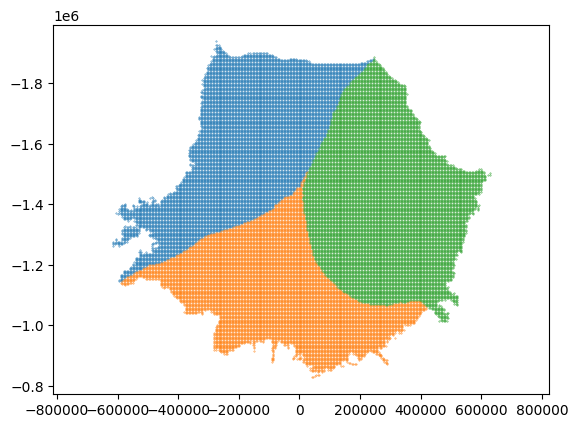

In [4]:
plt.scatter(x[in_NW], y[in_NW], s = 0.1)
plt.scatter(x[in_NO], y[in_NO], s = 0.1)
plt.scatter(x[in_NE], y[in_NE], s = 0.1)
plt.xlim(-8e5, 8e5)
plt.ylim(-0.8e6, -1.2e6)
plt.axis('equal')

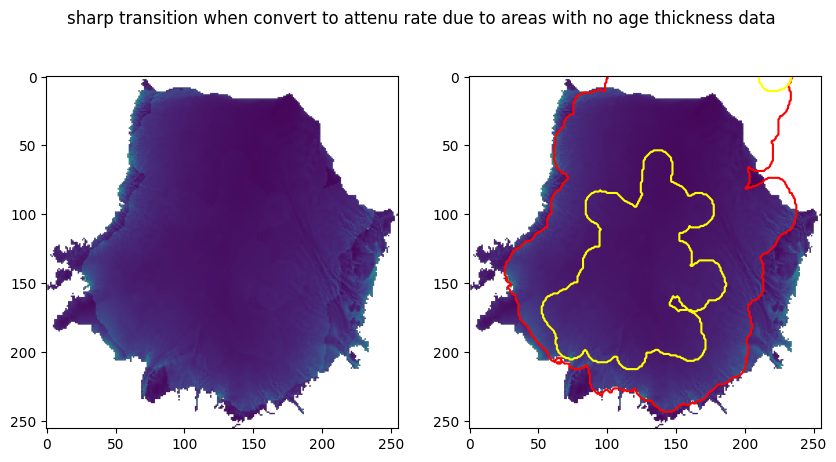

In [5]:
# load simulation data
Em = loadmat("../data/NGrIS/ensemble_data_pixelated/enthalpy_avg_grid.mat")['enthalpy_avg_grid']
pmp = loadmat("../data/NGrIS/ensemble_data_pixelated/pmp_grid.mat")['pmp_grid']
boundary = loadmat("../data/NGrIS/ensemble_data_pixelated/boundary_grid.mat")['boundary_grid']
radar_mask = loadmat("../data/NGrIS/ensemble_data_pixelated/radar_mask.mat")['radar_mask']
radar_mask = (radar_mask == 1)

# load holocene and LGP ice fraction data
Hol_depth = loadmat('../data/NGrIS/ensemble_data_pixelated/holocene_depth_grid.mat')['holocene_depth_grid']
Hol_depth_uncert = loadmat('../data/NGrIS/ensemble_data_pixelated/holocene_depth_uncert_grid.mat')['holocene_depth_uncert_grid']
LGP_depth = loadmat('../data/NGrIS/ensemble_data_pixelated/lgp_depth_grid.mat')['lgp_depth_grid']
LGP_depth_uncert = loadmat('../data/NGrIS/ensemble_data_pixelated/lgp_depth_uncert_grid.mat')['lgp_depth_uncert_grid']
H = loadmat('../data/NGrIS/ensemble_data_pixelated/H_grid.mat')['H_grid']

Hol_valid_mask = ~np.isnan(Hol_depth)
LGP_valid_mask = ~np.isnan(LGP_depth)

# original data without simulation with uncert
LGP_thickness = LGP_depth - Hol_depth
Hol_thickness = Hol_depth
LGP_f = LGP_thickness / H
Hol_f = Hol_thickness / H
Hol_f[np.isnan(Hol_f)] = 0
LGP_f[np.isnan(LGP_f)] = 0

Em = np.array(Em)
pmp = pmp[:, :, np.newaxis]
pmp = np.tile(pmp, (1, 1, Em.shape[2]))

# convert Em to attenu rate
Tm = ice.enthalpy_to_temperature(Em, Tpmp = pmp, istorch = False)

# convert Tm to attenu rate
# attenu_fromEm = ice.temperature_to_atten_rate_ice(Tm)

# attenu_fromEm = np.load('./saved_data/attenu_chemistry_samples.npz')['attenu_chemistry_samples']

attenu_fromEm = ice.temperature_to_atten_rate_mix_GrISfraction(T = Tm, 
                                                            Hol_f = np.tile(Hol_f[:, :, np.newaxis], (1, 1, Tm.shape[2])), 
                                                            LGP_f = np.tile(LGP_f[:, :, np.newaxis], (1, 1, Tm.shape[2])),
                                                            kind = "W97",
                                                            beta = 2.2,
                                                            )


non_convergence_idx = np.arange(attenu_fromEm.shape[2])[np.all(np.isnan(attenu_fromEm), axis = (0, 1))]
attenu_fromEm = np.delete(attenu_fromEm, non_convergence_idx, axis = 2)
# attenu_fromEm = np.moveaxis(attenu_fromEm, 2, 0) # sample, image_dimension, image_dimension

attenu_fromEm_mean = np.nanmean(attenu_fromEm)
attenu_fromEm_std = np.nanstd(attenu_fromEm)

# relaxationm to decrease magnitude of z-score, does not change shape of distributions
# better for training to avoid large magnitude z-score
# attenu_fromEm_std = 1

# attenu_fromEm_mean = np.tile(attenu_fromEm_mean, (1, 1, attenu_fromEm.shape[2]))
# attenu_fromEm_std = np.tile(attenu_fromEm_std, (1, 1, attenu_fromEm.shape[2]))
attenu_fromEm_standard = (attenu_fromEm - attenu_fromEm_mean) / attenu_fromEm_std

# transformer_attenu = sklearn.preprocessing.StandardScaler()

# Eb_standard = transformer_Eb.fit_transform(Eb.reshape(-1, 1))
# Eb_standard = Eb_standard.reshape(int(np.sqrt(np.shape(Eb_standard)[0]/Eb.shape[2])), int(np.sqrt(np.shape(Eb_standard)[0]/Eb.shape[2])), Eb.shape[2])

# transformer_attenu = sklearn.preprocessing.StandardScaler()
# attenu_fromEm_standard = transformer_attenu.fit_transform(attenu_fromEm.reshape(attenu_fromEm.shape[0], -1))
# attenu_fromEm_standard = attenu_fromEm_standard.reshape((attenu_fromEm_standard.shape[0], 256, 256))
# attenu_fromEm_standard = np.moveaxis(attenu_fromEm_standard, 0, 2)
# attenu_fromEm_standard = attenu_fromEm_standard.reshape(int(np.sqrt(np.shape(attenu_fromEm_standard)[0]/attenu_fromEm.shape[2])), int(np.sqrt(np.shape(attenu_fromEm_standard)[0]/attenu_fromEm.shape[2])), attenu_fromEm.shape[2])

# Eb_standard = np.moveaxis(Eb_standard, -1, 0)
# Eb_standard = Eb_standard[:, np.newaxis, :, :]
# Eb_standard[np.isnan(Eb_standard)] = 0
# np.savez('Eb_standard.npz', Eb_standard = Eb_standard)
# Eb_standard = torch.tensor(Eb_standard).float()

fig, ax = plt.subplots(1, 2, figsize = (10, 5))

ax[0].imshow(attenu_fromEm_standard[:, :, 0])

ax[1].imshow(attenu_fromEm_standard[:, :, 0])
ax[1].contour(Hol_valid_mask, colors='red')
ax[1].contour(LGP_valid_mask, colors='yellow')

fig.suptitle("sharp transition when convert to attenu rate due to areas with no age thickness data")

# filter points not on radar flight path
# note: nan is filled with 0 for PCA
attenu_fromEm_standard[np.tile(radar_mask[:, :, np.newaxis], (1, 1, attenu_fromEm_standard.shape[2])) != 1] = 0
attenu_fromEm_standard = np.moveaxis(attenu_fromEm_standard, -1, 0)
attenu_fromEm_standard = attenu_fromEm_standard[:, np.newaxis, :, :]
attenu_fromEm_standard[np.isnan(attenu_fromEm_standard)] = 0
attenu_fromEm_standard = torch.tensor(attenu_fromEm_standard).float()

# saved standardized data and transformer
# joblib.dump(transformer_attenu, f'./saved_data/transformer_attenu.pkl')
np.savez('./saved_data/attenu_fromEm_standard.npz', attenu_fromEm_standard = attenu_fromEm_standard)

Text(0, 0.5, '$N_a$ std')

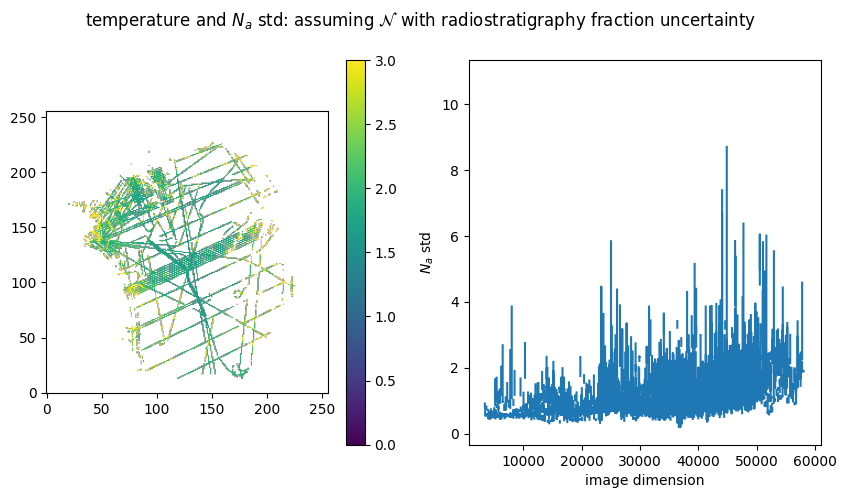

In [9]:
radar_temp_avg_samples_grid = loadmat('../data/NGrIS/ensemble_data_pixelated/radar_temp_avg_samples_grid.mat')['radar_temp_avg_samples_grid']
radar_temp_avg_samples_grid = radar_temp_avg_samples_grid[:, :, 0, :]

attenu_obs_samples = ice.temperature_to_atten_rate_ice(radar_temp_avg_samples_grid)

fig, ax = plt.subplots(1, 2, figsize = (10, 5))

fig.suptitle(rf'temperature and $N_a$ std: assuming $\mathcal{{N}}$ with radiostratigraphy fraction uncertainty')

im0 = ax[0].imshow(np.nanstd(radar_temp_avg_samples_grid, axis = 2), vmin = 0, vmax = 3)
ax[0].invert_yaxis()
plt.colorbar(im0)

ax[1].plot(np.nanstd(attenu_obs_samples, axis = 2).flatten())
ax[1].set_xlabel(rf"image dimension")
ax[1].set_ylabel(rf"$N_a$ std")

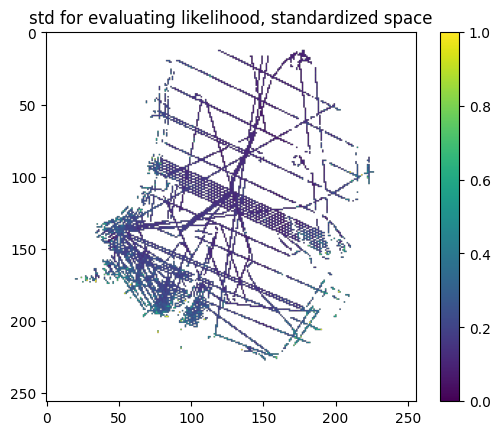

In [10]:
std_attenu_obs_samples = np.nanstd(attenu_obs_samples, axis = 2)
# for empty pixel or pixel with very small std
# use std = very small number to avoid log(0) when calculating likelihood
std_attenu_obs_samples[std_attenu_obs_samples < 1e-1] = 1e-1
std_attenu_obs_samples_standard = std_attenu_obs_samples / attenu_fromEm_std
im1 = plt.imshow(std_attenu_obs_samples_standard, vmin = 0, vmax = 1)
plt.colorbar(im1)
plt.title("std for evaluating likelihood, standardized space")

std_attenu_obs_samples_standard = std_attenu_obs_samples_standard.flatten()

/tmp/ipykernel_4572/2958945670.py:1: RuntimeWarning: Mean of empty slice
  attenu_fromEm_NW_mean = np.nanmean(attenu_fromEm, axis = 2)[in_NW & radar_mask]
/tmp/ipykernel_4572/2958945670.py:2: RuntimeWarning: Mean of empty slice
  attenu_fromEm_NO_mean = np.nanmean(attenu_fromEm, axis = 2)[in_NO & radar_mask]
/tmp/ipykernel_4572/2958945670.py:3: RuntimeWarning: Mean of empty slice
  attenu_fromEm_NE_mean = np.nanmean(attenu_fromEm, axis = 2)[in_NE & radar_mask]
/tmp/ipykernel_4572/2958945670.py:8: RuntimeWarning: Mean of empty slice
  attenu_obs_samples_mean = np.nanmean(attenu_obs_samples, axis = 2)
/tmp/ipykernel_4572/2958945670.py:21: RuntimeWarning: Mean of empty slice
  ax[1].hist(np.nanmean(attenu_fromEm, axis = 2)[radar_mask], bins = 200, alpha = 0.5, density = True, histtype='step', label = 'ensemble mean');


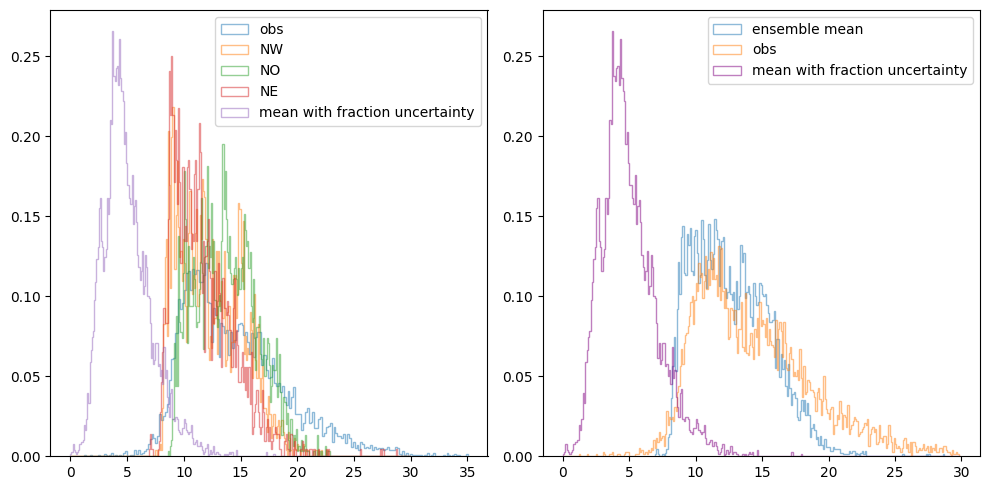

In [11]:
attenu_fromEm_NW_mean = np.nanmean(attenu_fromEm, axis = 2)[in_NW & radar_mask]
attenu_fromEm_NO_mean = np.nanmean(attenu_fromEm, axis = 2)[in_NO & radar_mask]
attenu_fromEm_NE_mean = np.nanmean(attenu_fromEm, axis = 2)[in_NE & radar_mask]

attenu_obs = loadmat('../data/NGrIS/ensemble_data_pixelated/radar_attenu_grid.mat')['radar_attenu_grid']

# this is the mean of samples generated from radiostratigraphy fraction uncertainty
attenu_obs_samples_mean = np.nanmean(attenu_obs_samples, axis = 2)

fig, ax = plt.subplots(1,2, figsize = (10, 5))
# plt.hist(attenu_fromEm_mean_NW, bins = 200, alpha = 0.5, density = True);

bins = np.arange(0, 30, 0.1)
ax[0].hist(attenu_obs[~np.isnan(attenu_obs)], bins = 200, alpha = 0.5, density = True, histtype='step', label = 'obs');
ax[0].hist(attenu_fromEm_NW_mean, bins = bins, alpha = 0.5, density = True,  histtype='step', label = 'NW');
ax[0].hist(attenu_fromEm_NO_mean, bins = bins, alpha = 0.5, density = True,  histtype='step', label = 'NO');
ax[0].hist(attenu_fromEm_NE_mean, bins = bins, alpha = 0.5, density = True,  histtype='step', label = 'NE');
ax[0].hist(attenu_obs_samples_mean.flatten(), bins = bins, alpha = 0.5, density = True,  histtype='step', label = 'mean with fraction uncertainty');
ax[0].legend()

ax[1].hist(np.nanmean(attenu_fromEm, axis = 2)[radar_mask], bins = 200, alpha = 0.5, density = True, histtype='step', label = 'ensemble mean');
ax[1].hist(attenu_obs.flatten(), bins = bins, alpha = 0.5, density = True, histtype='step', label = 'obs');
ax[1].hist(attenu_obs_samples_mean.flatten(), bins = bins, alpha = 0.5, density = True,  histtype='step', color = 'purple', label = 'mean with fraction uncertainty');
ax[1].legend()

fig.tight_layout()

/tmp/ipykernel_4572/2883883078.py:4: RuntimeWarning: Mean of empty slice
  ensemble_mean_mode = mode(np.round(np.nanmean(attenu_fromEm, axis = 2).flatten(), 1), nan_policy='omit').mode
/tmp/ipykernel_4572/2883883078.py:36: RuntimeWarning: Mean of empty slice
  ax[1].hist(np.nanmean(attenu_fromEm, axis = 2)[radar_mask], bins = 500, alpha = 0.5, density = True, histtype='step', label = 'ensemble mean');


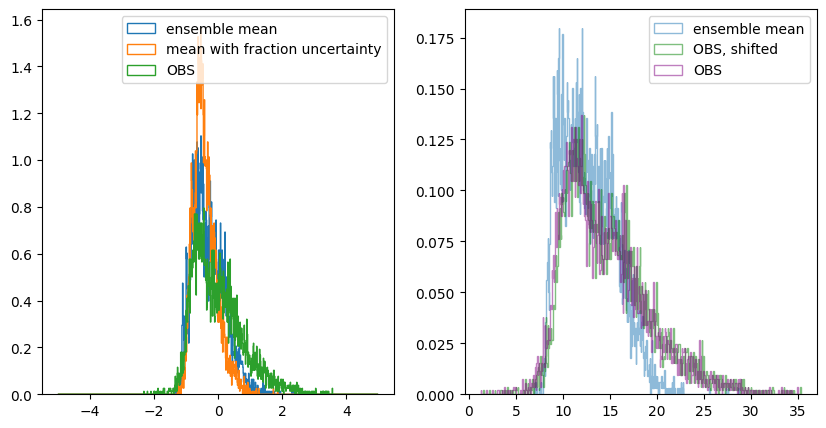

In [50]:
# attenu_obs_standard = transformer_attenu.transform(attenu_obs.reshape(1, -1))

from scipy.stats import mode
ensemble_mean_mode = mode(np.round(np.nanmean(attenu_fromEm, axis = 2).flatten(), 1), nan_policy='omit').mode
obs_samples_mode = mode(np.round(attenu_obs_samples_mean.flatten(), 1), nan_policy='omit').mode
obs_mode = mode(np.round(attenu_obs.flatten(), 1), nan_policy='omit').mode

attenu_obs_samples_mean_standard = (attenu_obs_samples_mean + (ensemble_mean_mode - obs_samples_mode) - attenu_fromEm_mean) / attenu_fromEm_std
attenu_obs_samples_mean_standard = attenu_obs_samples_mean_standard.flatten()

# # temporary fix, aftering shifting by mode
# attenu_obs_standard = attenu_obs + (ensemble_mean_mode - obs_mode)
# attenu_obs_standard[attenu_obs_standard < 1e-2] = 1e-2

attenu_obs_standard = attenu_obs.copy()
attenu_obs_standard = (attenu_obs_standard - attenu_fromEm_mean) / attenu_fromEm_std
attenu_obs_standard = attenu_obs_standard.flatten()


# plt.hist(attenu_obs_samples_mean_standard.flatten(), alpha = 0.5)

# attenu_obs_standard[np.isnan(attenu_obs_standard)] = 0

fig, ax = plt.subplots(1,2, figsize = (10, 5))
# plt.hist(attenu_fromEm_mean_NW, bins = 200, alpha = 0.5, density = True);


bins = np.arange(-5, 5, 0.01)
ax[0].hist(attenu_fromEm_standard[0, 0, :, :][radar_mask].flatten(), bins = bins, density = True, histtype='step', label = 'ensemble mean');
ax[0].hist(attenu_obs_samples_mean_standard[~np.isnan(attenu_obs_samples_mean_standard) & radar_mask.flatten()], bins = bins, density = True, histtype='step', label = 'mean with fraction uncertainty');
ax[0].hist(attenu_obs_standard[radar_mask.flatten()].flatten(), bins = bins, density = True, histtype='step', label = 'OBS');

ax[0].legend()

bins = np.arange(0, 30, 0.01)
ax[1].hist(np.nanmean(attenu_fromEm, axis = 2)[radar_mask], bins = 500, alpha = 0.5, density = True, histtype='step', label = 'ensemble mean');
ax[1].hist((attenu_obs[radar_mask]).flatten() + (ensemble_mean_mode - obs_mode), bins = 500, alpha = 0.5, density = True,  histtype='step', color = 'green', label = 'OBS, shifted');
ax[1].hist((attenu_obs[radar_mask]).flatten(), bins = 500, alpha = 0.5, density = True, histtype='step', color = 'purple', label = 'OBS');
ax[1].legend()

attenu_obs_samples_mean_standard[np.isnan(attenu_obs_samples_mean_standard)] = 0
attenu_obs_standard[np.isnan(attenu_obs_standard)] = 0

/tmp/ipykernel_4572/2753887529.py:1: RuntimeWarning: Mean of empty slice
  pixel_mean_attenu_fromEm = np.nanmean(attenu_fromEm, axis = 2)


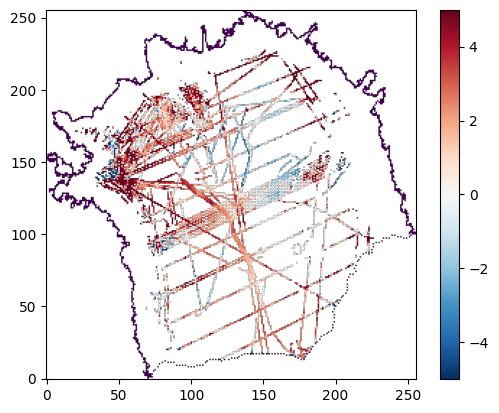

In [51]:
pixel_mean_attenu_fromEm = np.nanmean(attenu_fromEm, axis = 2)
pixel_mean_attenu_fromEm[~radar_mask] = np.nan

vmin = -5
vmax = 5
cb1 = plt.imshow((attenu_obs) + (ensemble_mean_mode - obs_mode) - pixel_mean_attenu_fromEm, vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
plt.colorbar(cb1)
# plt.gca().invert_yaxis()
plt.imshow(boundary)
plt.gca().invert_yaxis()

/tmp/ipykernel_4572/4039714012.py:5: RuntimeWarning: Mean of empty slice
  standard_1 = (attenu_fromEm - np.tile(np.nanmean(attenu_fromEm, axis = 2)[:, :, np.newaxis], (1, 1, 209))) / np.tile(np.nanstd(attenu_fromEm, axis = 2)[:, :, np.newaxis], (1, 1, 209))
/home/leo/Documents/Glaciology/calibrated-prior/.venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


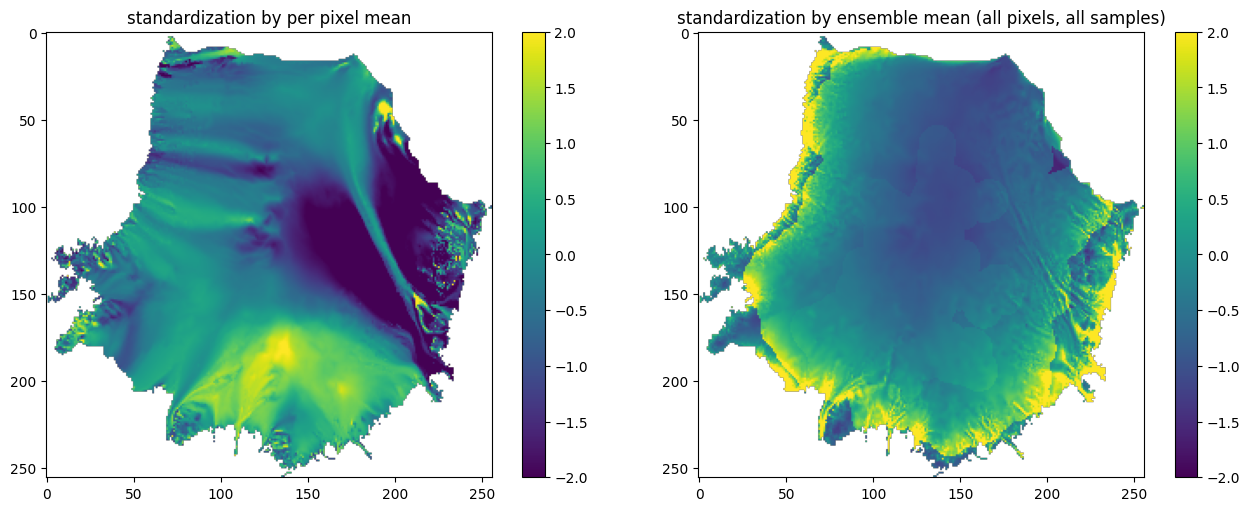

In [52]:
# standardization method comparison

fig, ax = plt.subplots(1,2, figsize = (13, 5), layout="constrained")

standard_1 = (attenu_fromEm - np.tile(np.nanmean(attenu_fromEm, axis = 2)[:, :, np.newaxis], (1, 1, 209))) / np.tile(np.nanstd(attenu_fromEm, axis = 2)[:, :, np.newaxis], (1, 1, 209))
standard_2 = (attenu_fromEm - np.nanmean(attenu_fromEm)) / np.nanstd(attenu_fromEm)

vmin = -2
vmax = 2

im0 = ax[0].imshow(standard_1[:, :, 3], vmin = vmin, vmax = vmax)
ax[0].set_title("standardization by per pixel mean")

im1 = ax[1].imshow(standard_2[:, :, 3], vmin = vmin, vmax = vmax)
ax[1].set_title("standardization by ensemble mean (all pixels, all samples)")

plt.colorbar(im0)
plt.colorbar(im1)

## PCA

In [53]:
# # detect if there are repeated samples in ensemble data
# unique_count = []
# for i in range(attenu_latent.shape[1]):
#     unique_count.append(torch.unique(attenu_latent[:, i]).shape[0])

# load data: attenuation rate in PCA latent space
#num_epochs = 50

# attenu_pca = joblib.load('./saved_data/attenu_pca.pkl')
#attenu_pca = sklearn.decomposition.PCA(n_components = 32)

attenu_pca = sklearn.decomposition.PCA(n_components = 32)

attenu_pca.fit(attenu_fromEm_standard[:, 0, :, :].reshape((-1, attenu_fromEm_standard.shape[2] ** 2)))

# joblib.dump(attenu_pca, './saved_data/attenu_pca.pkl')

attenu_latent = attenu_pca.transform(attenu_fromEm_standard[:, 0, :, :].reshape((-1, attenu_fromEm_standard.shape[2] ** 2)))
attenu_latent = torch.tensor(attenu_latent).float()


In [54]:
batch_size = 16
# train val test split
attenu_latent_dataset = TensorDataset(attenu_latent, attenu_latent)
#attenu_latent_dataset = TensorDataset(attenu_latent_standard, attenu_latent_standard)

train_size = (int(0.7 * len(attenu_latent_dataset)) // batch_size) * batch_size
val_size = int((len(attenu_latent_dataset) - train_size)/2)
test_size = int(len(attenu_latent_dataset) - train_size - val_size)

generator = torch.Generator().manual_seed(42)
attenu_latent_train_dataset, attenu_latent_val_dataset, attenu_latent_test_dataset = random_split(attenu_latent_dataset, [train_size, val_size, test_size], generator=generator)

attenu_latent_train_dataloader = DataLoader(attenu_latent_train_dataset, batch_size = batch_size, shuffle = 1)
attenu_latent_val_dataloader = DataLoader(attenu_latent_val_dataset, batch_size = batch_size, shuffle = 1)
attenu_latent_test_dataloader = DataLoader(attenu_latent_test_dataset, batch_size = batch_size, shuffle = 1)

print(f"train size: {train_size}, val_size: {val_size}, test_size: {test_size}")

train size: 144, val_size: 32, test_size: 33


Text(0.5, 1.0, 'cumulative explained variance')

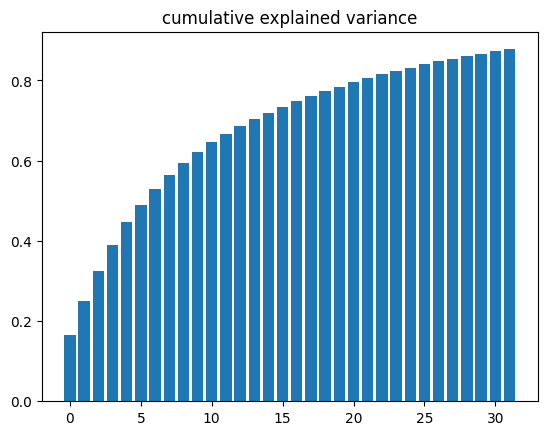

In [55]:
plt.bar(np.arange(np.cumsum(attenu_pca.explained_variance_ratio_).shape[0]), height = np.cumsum(attenu_pca.explained_variance_ratio_))
plt.title("cumulative explained variance")

Text(0.5, 0, 'latent space')

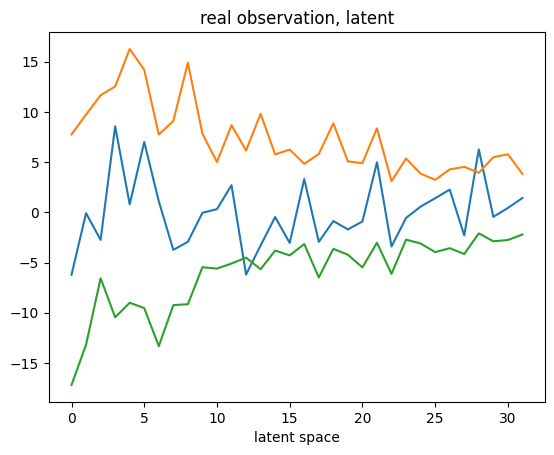

In [56]:
attenu_obs_samples_mean_latent = attenu_pca.transform(attenu_obs_samples_mean_standard.reshape(1, -1))
plt.plot(attenu_obs_samples_mean_latent.flatten(), label = 'obs')
plt.plot(torch.max(attenu_latent, axis = 0)[0], label = 'ensemble max')
plt.plot(torch.min(attenu_latent, axis = 0)[0], label = 'ensemble min')
plt.title("real observation, latent")
plt.xlabel("latent space")

# Training

## Architecture (MaskedAffineAutoregressive)

In [59]:
# # Set up model_nf
# # in_features = int(attenu_latent.shape[1]/2)

# # Define list of flows
# num_layers = 2
# flows = []
# for i in range(num_layers):
#     flows.append(nf.flows.MaskedAffineAutoregressive(32, 64))

# # base distribution is a Gaussian with num of dimension same as training data
# base = nf.distributions.base.DiagGaussian(32)

# # Construct flow model_nf
# model_nf = nf.NormalizingFlow(base, flows)

# model_nf

## Architecture (normflows, real NVP)

In [60]:
# Set up model_nf
in_features = int(attenu_latent.shape[1]/2)

# Define list of flows
num_layers = 4
flows = []
for i in range(num_layers):
    param_map = nf.nets.MLP([in_features, 64, 256, 64, in_features * 2], init_zeros=True, leaky = 0.01)
    # Add flow layer
    flows.append(nf.flows.AffineCouplingBlock(param_map))
    # Swap dimensions
    flows.append(nf.flows.Permute(in_features * 2, mode='shuffle'))

# base distribution is a Gaussian with num of dimension same as training data
base = nf.distributions.base.DiagGaussian(in_features * 2)

# Construct flow model_nf
model_nf = nf.NormalizingFlow(base, flows)

model_nf

NormalizingFlow(
  (q0): DiagGaussian()
  (flows): ModuleList(
    (0): AffineCouplingBlock(
      (flows): ModuleList(
        (0): Split()
        (1): AffineCoupling(
          (param_map): MLP(
            (net): Sequential(
              (0): Linear(in_features=16, out_features=64, bias=True)
              (1): LeakyReLU(negative_slope=0.01)
              (2): Linear(in_features=64, out_features=256, bias=True)
              (3): LeakyReLU(negative_slope=0.01)
              (4): Linear(in_features=256, out_features=64, bias=True)
              (5): LeakyReLU(negative_slope=0.01)
              (6): Linear(in_features=64, out_features=32, bias=True)
            )
          )
        )
        (2): Merge()
      )
    )
    (1): Permute()
    (2): AffineCouplingBlock(
      (flows): ModuleList(
        (0): Split()
        (1): AffineCoupling(
          (param_map): MLP(
            (net): Sequential(
              (0): Linear(in_features=16, out_features=64, bias=True)
             

In [61]:
# using linear regression to prevent overfitting
window_size = 50

reg = sklearn.linear_model.LinearRegression()
window = np.arange(window_size).reshape(-1, 1)

# Train model_nf
max_epoch = 5000
early_stopping_threshold = 1e-3

epoch_loss = np.array([])
epoch_loss_val = np.array([])

#optimizer = torch.optim.Adam(model_nf.parameters(), lr=1e-5, weight_decay=1e-5)
optimizer = torch.optim.AdamW(model_nf.parameters(), lr=1e-6)
#optimizer = torch.optim.LBFGS(model_nf.parameters(), lr=1e-5)
model_nf.train()

try:
    for epoch in range(max_epoch):
        optimizer.zero_grad()

        start = torch.Event(enable_timing=True)
        end = torch.Event(enable_timing=True)
        start.record()

        running_loss = 0.0
        running_loss_val = 0.0

        for train_batch, _ in attenu_latent_train_dataloader:
            # Compute loss
            loss = model_nf.forward_kld(train_batch)
            
            # Do backprop and optimizer step
            if ~(torch.isnan(loss) | torch.isinf(loss)):
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * train_batch.size(0)

        for val_batch, _ in attenu_latent_val_dataloader:
            # Compute loss
            val_loss = model_nf.forward_kld(val_batch)

            if ~(torch.isnan(val_loss) | torch.isinf(val_loss)):
                running_loss_val += val_loss.item() * val_batch.size(0)
        
        epoch_loss = np.append(epoch_loss, running_loss / len(attenu_latent_train_dataloader.dataset))
        epoch_loss_val = np.append(epoch_loss_val, running_loss_val / len(attenu_latent_val_dataloader.dataset))

        if epoch >= window.shape[0]:
            #print(epoch_loss[-window_size:])
            #print(epoch_loss_val[-window_size:])
            reg.fit(window, epoch_loss[-window_size:])
            epoch_loss_slope = reg.coef_


            reg.fit(window, epoch_loss_val[-window_size:])
            epoch_loss_val_slope = reg.coef_
            
            print(f"Epoch validation loss slope: {epoch_loss_val_slope}")
            print(f"Epoch loss slope: {epoch_loss_slope}")

            if (epoch_loss_slope > -early_stopping_threshold) or (epoch_loss_val_slope > -early_stopping_threshold):
                print("Early stopping")
                break

        end.record()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        print(f"Epoch [{epoch + 1}/{max_epoch}], loss: {epoch_loss[epoch]:.4f}, validation loss: {epoch_loss_val[epoch]:.4f}, time elapsed = {start.elapsed_time(end)/1000:.2f} s")
        
    torch.save(model_nf.state_dict(), f'./saved_data/realNVP.pth')
    np.savez(f'./saved_data/realNVP_loss.npz',epoch_loss = epoch_loss, epoch_loss_val = epoch_loss_val) 

except KeyboardInterrupt:
    torch.save(model_nf.state_dict(), f'./saved_data/realNVP.pth')
    np.savez(f'./saved_data/realNVP_loss.npz',epoch_loss = epoch_loss, epoch_loss_val = epoch_loss_val)


Epoch [1/5000], loss: 85.4048, validation loss: 84.1900, time elapsed = 0.02 s
Epoch [2/5000], loss: 85.3933, validation loss: 84.1804, time elapsed = 0.02 s
Epoch [3/5000], loss: 85.3793, validation loss: 84.1719, time elapsed = 0.02 s
Epoch [4/5000], loss: 85.3698, validation loss: 84.1633, time elapsed = 0.01 s
Epoch [5/5000], loss: 85.3593, validation loss: 84.1538, time elapsed = 0.01 s
Epoch [6/5000], loss: 85.3472, validation loss: 84.1433, time elapsed = 0.01 s
Epoch [7/5000], loss: 85.3317, validation loss: 84.1337, time elapsed = 0.01 s
Epoch [8/5000], loss: 85.3214, validation loss: 84.1241, time elapsed = 0.02 s
Epoch [9/5000], loss: 85.3088, validation loss: 84.1146, time elapsed = 0.02 s
Epoch [10/5000], loss: 85.2977, validation loss: 84.1045, time elapsed = 0.01 s
Epoch [11/5000], loss: 85.2843, validation loss: 84.0947, time elapsed = 0.01 s
Epoch [12/5000], loss: 85.2727, validation loss: 84.0844, time elapsed = 0.01 s
Epoch [13/5000], loss: 85.2583, validation loss: 

Text(0.5, 0.98, 'KL-divergence = -log(mean(prob))')

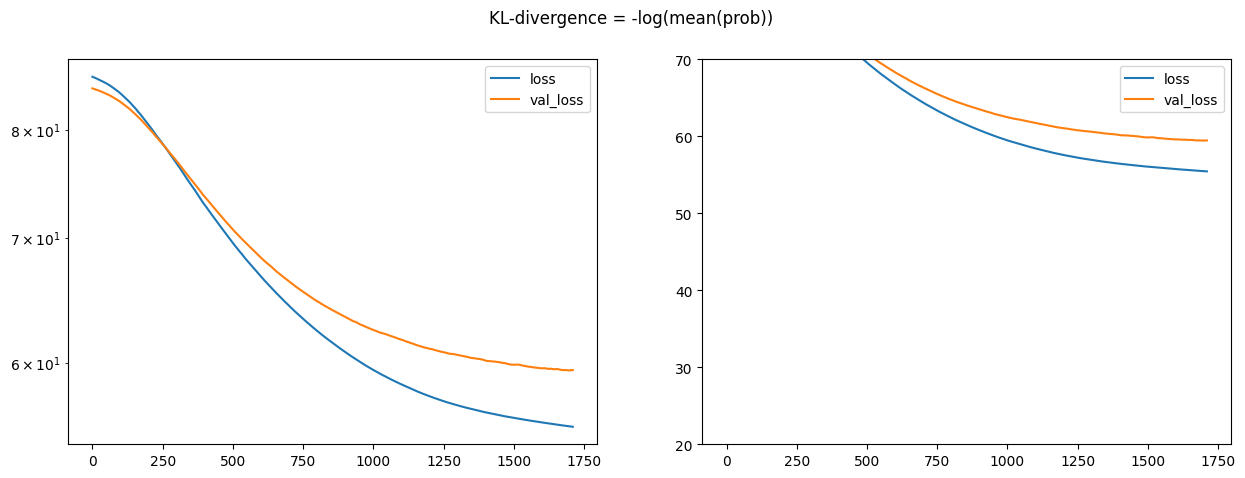

<Figure size 1000x500 with 0 Axes>

In [62]:
# Plot loss
# epoch_loss = np.load('../notebooks/saved_data/realNVP_loss_32_5e-05_128_64_1.npz')['epoch_loss']
# epoch_loss_val = np.load('../notebooks/saved_data/realNVP_loss_32_5e-05_128_64_1.npz')['epoch_loss_val']

fig, ax = plt.subplots(1,2, figsize = (15, 5))
plt.figure(figsize=(10, 5))
ax[0].plot(epoch_loss, label='loss')
ax[0].plot(epoch_loss_val, label='val_loss')
ax[0].legend()
ax[0].set_yscale('log')

ax[1].plot(epoch_loss, label='loss')
ax[1].plot(epoch_loss_val, label='val_loss')
ax[1].legend()
ax[1].set_ylim(20, 70)

fig.suptitle('KL-divergence = -log(mean(prob))')

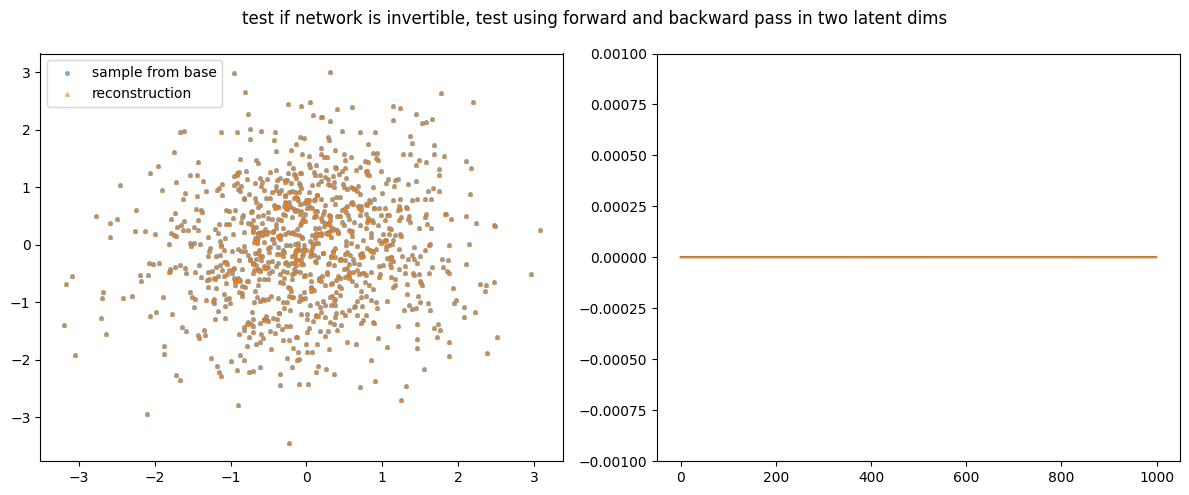

In [63]:
# model_nf.load_state_dict(torch.load('../notebooks/saved_data/realNVP_32_5e-05_128_64_2.pth', weights_only=True))
model_nf.eval()

x0 = base.sample(1000)
x1_from_x0 = model_nf.forward(x0)
x1 = model_nf.sample(1000)[0]
x0_from_x1_from_x0 = model_nf.inverse(x1_from_x0)

x0 = x0.detach().numpy()
x1 = x1.detach().numpy()
x1_from_x0 = x1_from_x0.detach().numpy()
x0_from_x1_from_x0 = x0_from_x1_from_x0.detach().numpy()

fig, ax = plt.subplots(1, 2, figsize = (12, 5))
ax[0].scatter(x0[:, 0], x0[:, 1], alpha = 0.5, label = 'sample from base', s = 7)
#plt.scatter(x1[:, 0], x1[:, 1])
#plt.scatter(x1_from_x0[:, 0], x1_from_x0[:, 1])
ax[0].scatter(x0_from_x1_from_x0[:, 0], x0_from_x1_from_x0[:, 1], alpha = 0.5, label = 'reconstruction', marker = '^', s = 7)
ax[0].legend()


ax[1].plot(x0_from_x1_from_x0[:, 0] - x0[:, 0])
ax[1].plot(x0_from_x1_from_x0[:, 1] - x0[:, 1])
ax[1].set_ylim(-1e-3, 1e-3)

fig.suptitle("test if network is invertible, test using forward and backward pass in two latent dims")
fig.tight_layout()

# Sampling

Text(0.5, 0.98, 'comparing samples drawn from NF prior and ensemble')

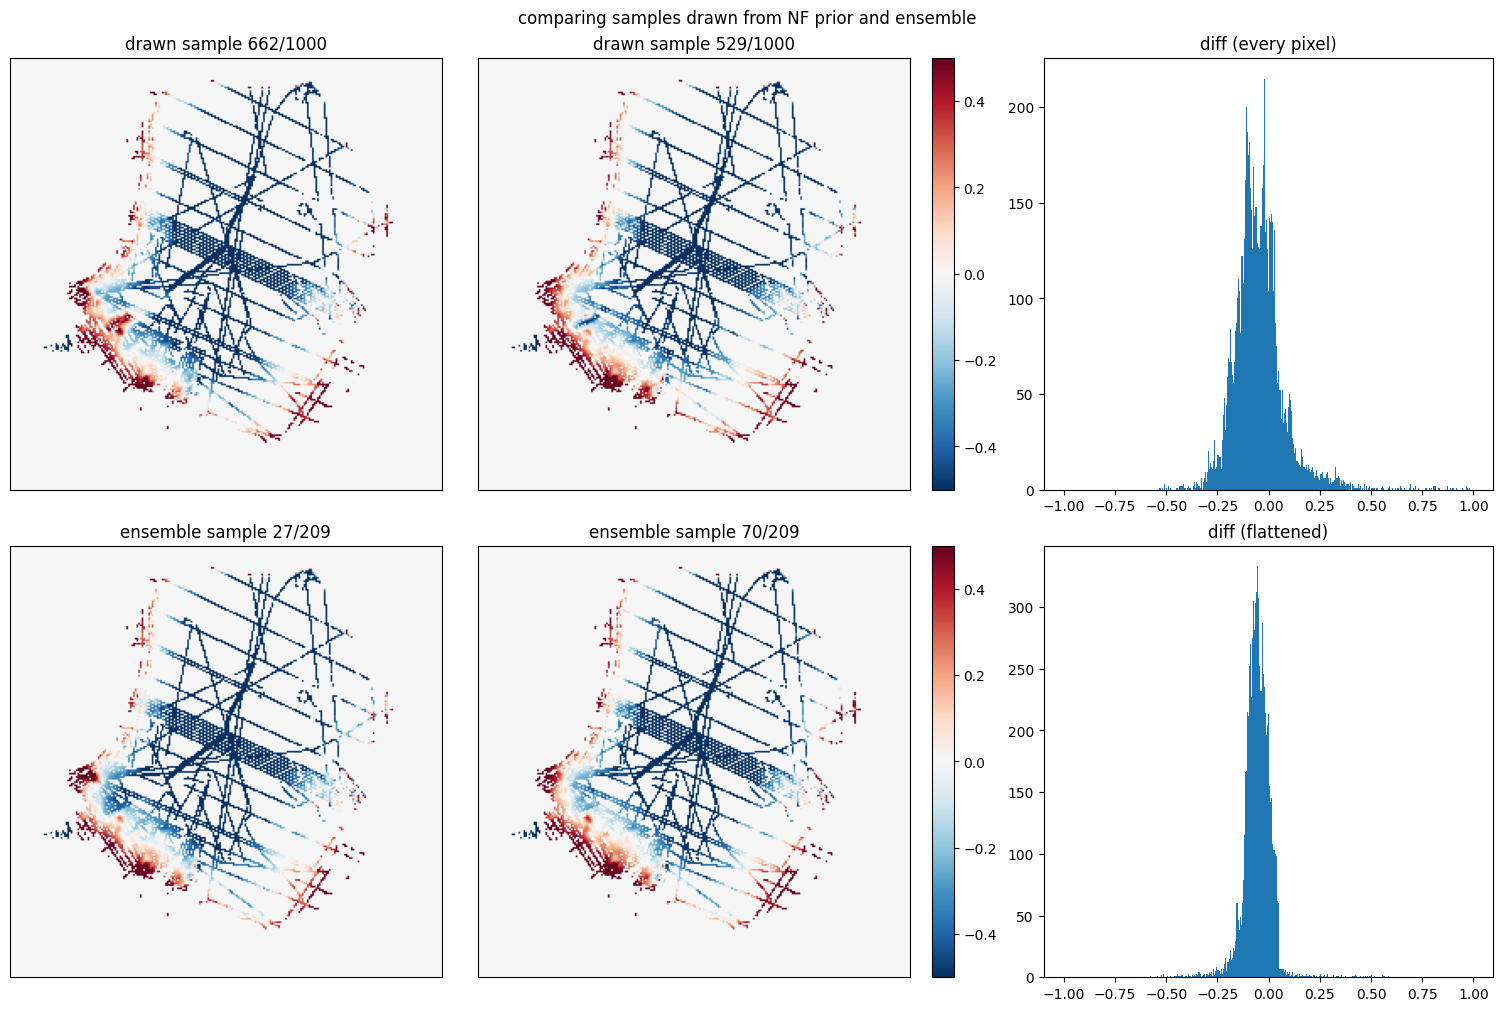

In [64]:
#attenu_pca = joblib.load('../testing/attenu_pca2026-06-12 15:13:52.857122.pkl')

attenu_samples_nf_latent, attenu_samples_log_prob = model_nf.sample(1000)
attenu_samples_nf_latent = attenu_samples_nf_latent.reshape((attenu_samples_nf_latent.shape[0], -1))
attenu_samples_nf_latent = attenu_samples_nf_latent[(~torch.isnan(attenu_samples_log_prob)) & (~torch.isinf(attenu_samples_log_prob)), :]
attenu_samples_nf_latent[attenu_samples_nf_latent == torch.nan] = 0
attenu_samples_nf_latent[attenu_samples_nf_latent == torch.inf] = 0
attenu_samples_nf_latent[attenu_samples_nf_latent == -torch.inf] = 0
# attenu_samples_nf_latent[torch.abs(attenu_samples_nf_latent) > 1e2] = 0
attenu_samples_nf = attenu_pca.inverse_transform(attenu_samples_nf_latent.detach().numpy())
attenu_samples_nf = attenu_samples_nf.reshape((attenu_samples_nf_latent.shape[0], 256, 256))

fig, ax = plt.subplots(2,3, figsize = (15, 10), layout="constrained")

vmin = -0.5
vmax = 0.5

rng = np.random.default_rng()
idx = rng.choice(attenu_samples_nf.shape[0], size=2, replace=False)

ax[0, 0].imshow(attenu_samples_nf[idx[0], :, :], vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[0, 0].set_title(f"drawn sample {idx[0]}/{attenu_samples_nf.shape[0]}")
ax[0, 0].set_xticks([])
ax[0, 0].set_yticks([])

im01 = ax[0, 1].imshow(attenu_samples_nf[idx[1], :, :], vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[0, 1].set_title(f"drawn sample {idx[1]}/{attenu_samples_nf.shape[0]}")
ax[0, 1].set_xticks([])
ax[0, 1].set_yticks([])
plt.colorbar(im01)

bins = np.arange(-1, 1, 0.005)

ax[0, 2].hist((attenu_samples_nf[idx[0], :, :] - attenu_samples_nf[idx[1], :, :])[radar_mask].flatten(), bins = bins)
ax[0, 2].set_title("diff (every pixel)")
# ax[2].xaxis.set_visible(False)





# ensemble samples
attenu_samples_ensemble = attenu_pca.inverse_transform(attenu_latent.detach().numpy().reshape(attenu_latent.shape[0], -1))
attenu_samples_ensemble = attenu_samples_ensemble.reshape((attenu_samples_ensemble.shape[0], 256, 256))

vmin = -0.5
vmax = 0.5

rng = np.random.default_rng()
idx = rng.choice(attenu_samples_ensemble.shape[0], size=2, replace=False)

ax[1, 0].imshow(attenu_samples_ensemble[idx[0], :, :], vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[1, 0].set_title(f"ensemble sample {idx[0]}/{attenu_samples_ensemble.shape[0]}")
ax[1, 0].set_xticks([])
ax[1, 0].set_yticks([])

im11 = ax[1, 1].imshow(attenu_samples_ensemble[idx[1], :, :], vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[1, 1].set_title(f"ensemble sample {idx[1]}/{attenu_samples_ensemble.shape[0]}")
ax[1, 1].set_xticks([])
ax[1, 1].set_yticks([])
plt.colorbar(im11)

ax[1, 2].hist((attenu_samples_ensemble[idx[0], :, :] - attenu_samples_ensemble[idx[1], :, :])[radar_mask].flatten(), bins = bins)
ax[1, 2].set_title("diff (flattened)")

fig.suptitle("comparing samples drawn from NF prior and ensemble")

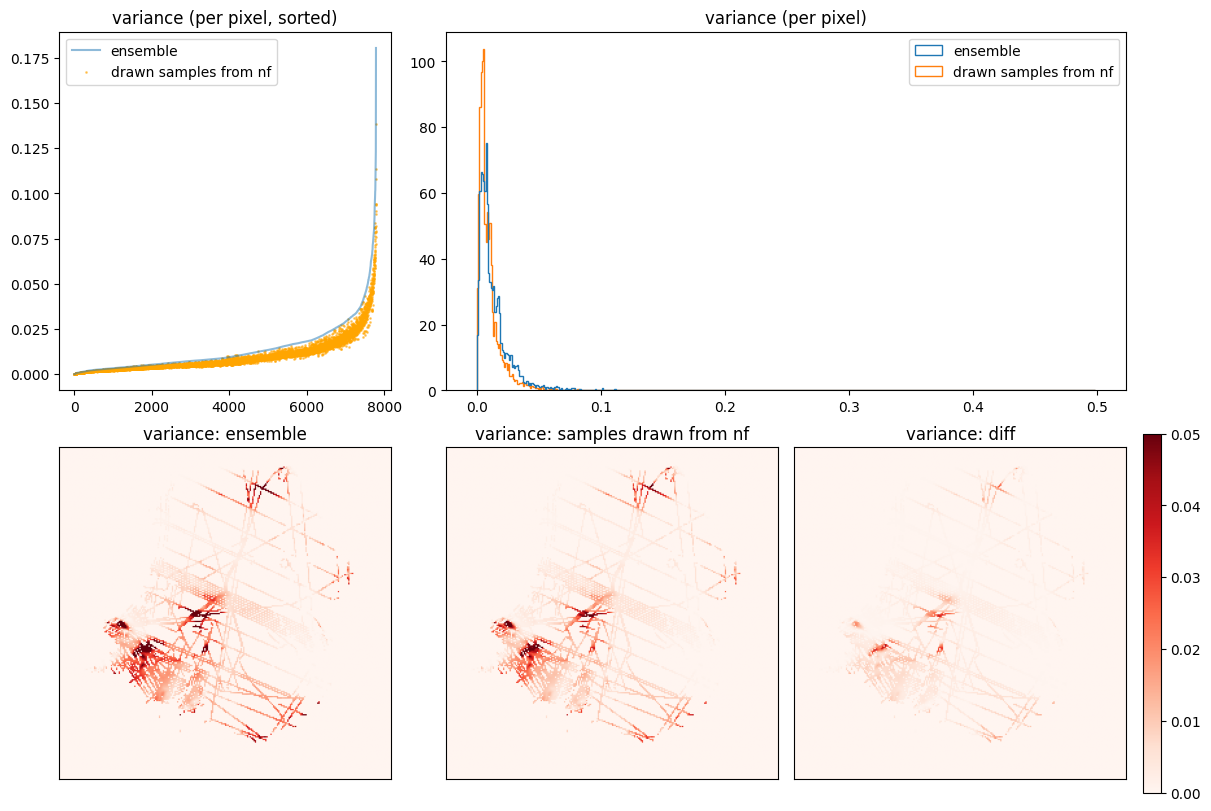

In [65]:
fig, ax = plt.subplot_mosaic([['A', 'B', 'B'],
                              ['C', 'D', 'E']],
                             figsize = (12, 8), layout = 'constrained')

var_attenu_ensemble = np.var(attenu_samples_ensemble, axis = 0)
var_attenu_nf = np.var(attenu_samples_nf, axis = 0)
sort_idx = np.argsort(var_attenu_ensemble[radar_mask].flatten())

ax['A'].plot(var_attenu_ensemble[radar_mask].flatten()[sort_idx], label = 'ensemble', alpha = 0.5, zorder = 3)
ax['A'].scatter(np.arange(0, var_attenu_nf[radar_mask].flatten().shape[0], 1), var_attenu_nf[radar_mask].flatten()[sort_idx], label = 'drawn samples from nf', alpha = 0.5, s = 1, c = 'orange')
ax['A'].set_title("variance (per pixel, sorted)")
ax['A'].legend()

bins = np.arange(0, 0.5, 0.001)
ax['B'].hist(var_attenu_ensemble[radar_mask].flatten(), label = 'ensemble', zorder = 3, bins = bins, density = True, histtype='step')
ax['B'].hist(var_attenu_nf[radar_mask].flatten(), label = 'drawn samples from nf', bins = bins, density = True, histtype='step')
ax['B'].set_title("variance (per pixel)")
ax['B'].legend()

vmin = 0
vmax = 0.05

im0 = ax['C'].imshow(var_attenu_ensemble, vmin = vmin, vmax = vmax, cmap = 'Reds')
ax['C'].set_title(f"variance: ensemble")
# ax['C'].set_axis_off()
ax['C'].set_xticks([])
ax['C'].set_yticks([])
ax['C'].set_box_aspect(1) 

im1 = ax['D'].imshow(var_attenu_nf, vmin = vmin, vmax = vmax, cmap = 'Reds')
ax['D'].set_title(f"variance: samples drawn from nf")
# ax['D'].set_axis_off()
ax['D'].set_xticks([])
ax['D'].set_yticks([])
ax['D'].set_box_aspect(1) 

im2 = ax['E'].imshow(var_attenu_ensemble - var_attenu_nf, vmin = vmin, vmax = vmax, cmap = 'Reds')
ax['E'].set_title(f"variance: diff")
# ax['E'].set_axis_off()
ax['E'].set_xticks([])
ax['E'].set_yticks([])
ax['E'].set_box_aspect(1) 
plt.colorbar(im2)

# fig.tight_layout()


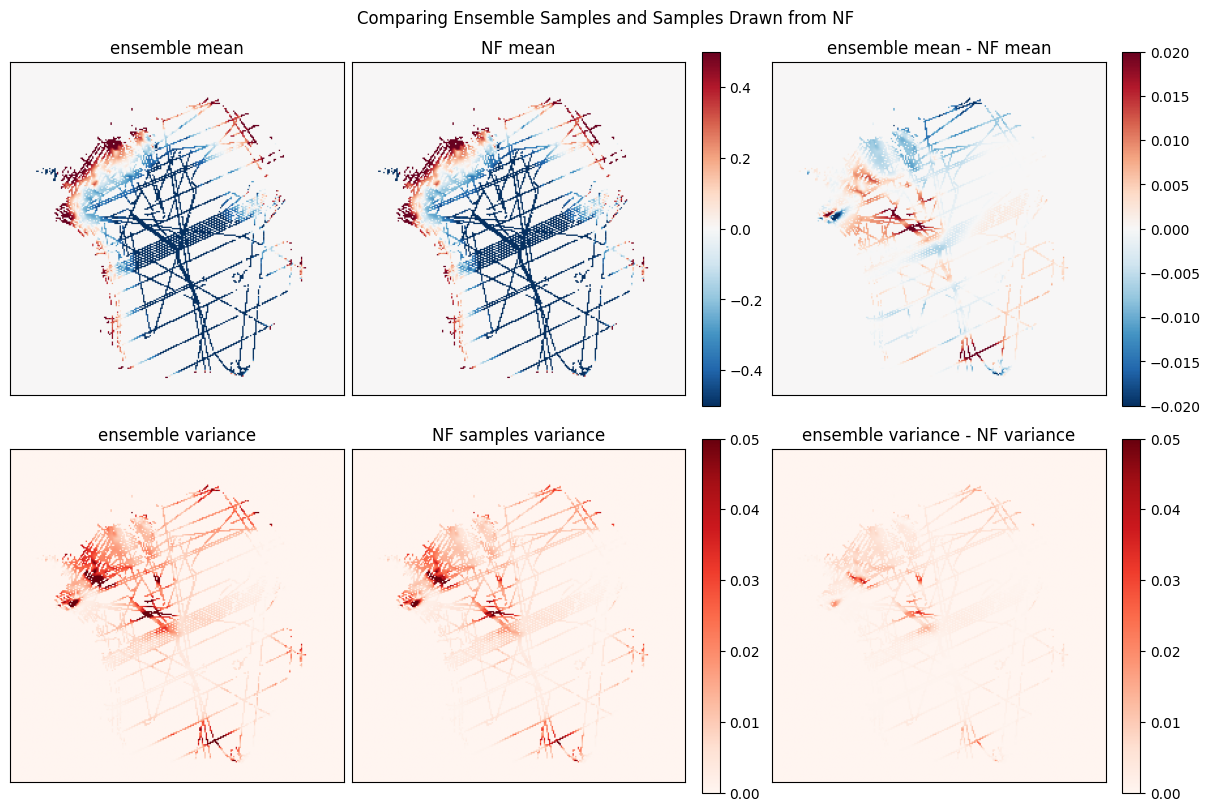

In [66]:
fig, ax = plt.subplot_mosaic([['A', 'B', 'C'],
                              ['D', 'E', 'F']],
                             figsize = (12, 8), layout = 'constrained')

vmin = -0.5
vmax = 0.5

ax['A'].imshow(np.nanmean(attenu_samples_ensemble, axis = 0), vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax['A'].set_title(f"ensemble mean")
# ax['A'].set_axis_off()
ax['A'].set_xticks([])
ax['A'].set_yticks([])
ax['A'].invert_yaxis()
ax['A'].set_box_aspect(1) 

im0 = ax['B'].imshow(np.nanmean(attenu_samples_nf, axis = 0), vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax['B'].set_title(f"NF mean")
# ax['B'].set_axis_off()
ax['B'].set_xticks([])
ax['B'].set_yticks([])
ax['B'].invert_yaxis()
ax['B'].set_box_aspect(1) 
plt.colorbar(im0)

vmin = -0.02
vmax = 0.02
im1 = ax['C'].imshow(np.nanmean(attenu_samples_ensemble, axis = 0) - np.nanmean(attenu_samples_nf, axis = 0), vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax['C'].set_title(f"ensemble mean - NF mean")
# ax['B'].set_axis_off()
ax['C'].set_xticks([])
ax['C'].set_yticks([])
ax['C'].invert_yaxis()
ax['C'].set_box_aspect(1) 
plt.colorbar(im1)

vmin = 0
vmax = 0.05

ax['D'].imshow(var_attenu_ensemble, vmin = vmin, vmax = vmax, cmap = 'Reds')
ax['D'].set_title(f"ensemble variance")
# ax['D'].set_axis_off()
ax['D'].set_xticks([])
ax['D'].set_yticks([])
ax['D'].invert_yaxis()
ax['D'].set_box_aspect(1) 

im2 = ax['E'].imshow(var_attenu_nf, vmin = vmin, vmax = vmax, cmap = 'Reds')
ax['E'].set_title(f"NF samples variance")
# ax['E'].set_axis_off()
ax['E'].set_xticks([])
ax['E'].set_yticks([])
ax['E'].invert_yaxis()
ax['E'].set_box_aspect(1)
plt.colorbar(im2)

vmin = 0
vmax = 0.05

im3 = ax['F'].imshow(var_attenu_ensemble - var_attenu_nf, vmin = vmin, vmax = vmax, cmap = 'Reds')
ax['F'].set_title(f"ensemble variance - NF variance")
# ax['F'].set_axis_off()
ax['F'].set_xticks([])
ax['F'].set_yticks([])
ax['F'].invert_yaxis()
ax['F'].set_box_aspect(1) 
plt.colorbar(im3)

fig.suptitle("Comparing Ensemble Samples and Samples Drawn from NF")
fig.savefig("../figs/ensemble_vs_nf.svg")
# fig.tight_layout()


In [67]:
torch.tensor(attenu_pca.transform(attenu_samples_nf[idx[0], :, :].flatten().reshape(1, -1))).to(torch.float32)[torch.newaxis, :]

tensor([[[-2.0486,  0.1048, -2.1956, -1.6543,  0.4016,  1.3409, -2.6772,
           0.4519,  0.4038,  2.2310, -2.8176, -1.4192,  1.0377, -1.3115,
          -2.5049,  0.2652, -0.1095,  0.0066,  0.3318,  4.6901, -0.1126,
          -0.6982,  0.9588,  0.3733, -0.2821,  0.2837,  0.7675,  0.0611,
           0.1525,  0.1315,  0.8839,  0.0704]]])

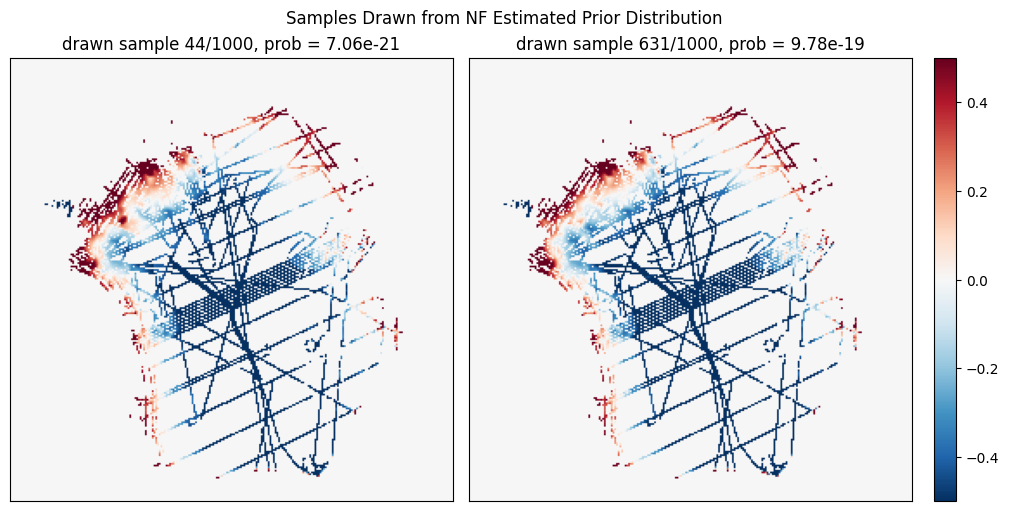

In [68]:
fig, ax = plt.subplots(1,2, figsize = (10, 5), layout="constrained")

vmin = -0.5
vmax = 0.5

rng = np.random.default_rng()
idx = rng.choice(attenu_samples_nf.shape[0], size=2, replace=False)

ax[0].imshow(attenu_samples_nf[idx[0], :, :], vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
prob0 = torch.exp(model_nf.log_prob(torch.tensor(attenu_pca.transform(attenu_samples_nf[idx[0], :, :].flatten().reshape(1, -1))).to(torch.float32))).detach().numpy()
ax[0].set_title(f"drawn sample {idx[0]}/{attenu_samples_nf.shape[0]}, prob = {prob0[0]:.2e}")
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].invert_yaxis()

im01 = ax[1].imshow(attenu_samples_nf[idx[1], :, :], vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
prob1 = torch.exp(model_nf.log_prob(torch.tensor(attenu_pca.transform(attenu_samples_nf[idx[1], :, :].flatten().reshape(1, -1))).to(torch.float32))).detach().numpy()
ax[1].set_title(f"drawn sample {idx[1]}/{attenu_samples_nf.shape[0]}, prob = {prob1[0]:.2e}")
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].invert_yaxis()
plt.colorbar(im01)

fig.suptitle("Samples Drawn from NF Estimated Prior Distribution")
fig.savefig("../figs/samples_from_prior.svg")

## Verify Autograd

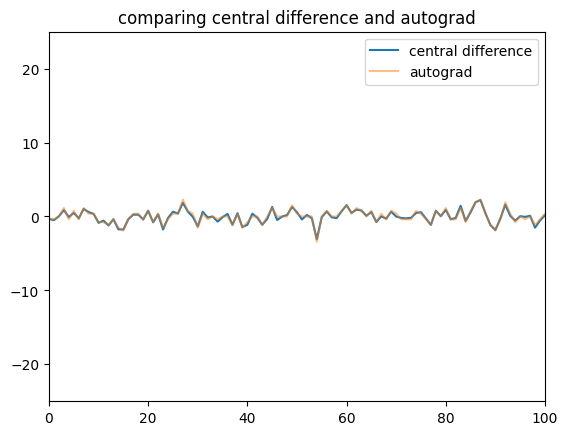

In [69]:
# z = base.sample(1)
# log_prob_z = base.log_prob(z)
# x, log_det_z_to_x = model_nf.forward_and_log_det(z)
# z_1, log_det_x_to_z = model_nf.inverse_and_log_det(x)
# x = model_nf.forward(z)
# log_prob_x = model_nf.log_prob(x)

# # note: log det have opposite sign as defined in this package
# # p(x) = p(z) + log(det(Jacobian(f(z->x)))) = p(z) - (log det output by model_nf.forward_and_log_det(z))
# log_det_z_to_x = -log_det_z_to_x
# log_det_x_to_z = -log_det_x_to_z

# autograd

z = base.sample(10)
log_prob_z = base.log_prob(z)
#x, log_det_z_to_x = model_nf.forward_and_log_det(z)
#z_1, log_det_x_to_z = model_nf.inverse_and_log_det(x)
x = model_nf.forward(z)
log_prob_x = model_nf.log_prob(x)

grad_autograd = torch.full(x.shape, float('nan'))

for i in range(len(log_prob_x)):
    grad_autograd[i, :] = torch.autograd.grad(log_prob_x[i], x, retain_graph= True)[0][i, :]

# central diff
grad_fd = torch.zeros(x.shape)

#step_sizes = float(10) ** (torch.arange(-7, -1, 0.1))
#diff_central = []
#diff_logp1_central = []

step = 5e-6

for i in range(grad_fd.shape[0]):
    for j in range(grad_fd.shape[1]):

        x_perturb_positive = x.clone().detach()
        x_perturb_positive = x_perturb_positive[i:i+1, :]
        x_perturb_positive[0,j] += step

        x_perturb_negative = x.clone().detach()
        x_perturb_negative = x_perturb_negative[i:i+1, :]
        x_perturb_negative[0,j] -= step

        log_prob_x_perturb_positive = model_nf.log_prob(x_perturb_positive)
        log_prob_x_perturb_negative = model_nf.log_prob(x_perturb_negative)

        diff_central = ((log_prob_x_perturb_positive - log_prob_x_perturb_negative)/(step * 2))
        #diff_central = ((log_p1_sample_perturb_positive - log_p1[i])/(step))
        grad_fd[i,j] = diff_central

grad_fd = grad_fd.detach().numpy()

plt.plot(grad_autograd.flatten(), label = 'central difference')
plt.plot(grad_fd.flatten(), alpha = 0.5, label = 'autograd')
plt.xlim((0, 100))
plt.ylim((-25, 25))
plt.title("comparing central difference and autograd")
plt.legend()

## HMC

In [70]:
# x = model_nf.sample(1)[0]
# log_p_prior = model_nf.log_prob(x)

# z = model_nf.inverse(x)
# z_image = torch.matmul(z, torch.tensor(attenu_pca.components_).float()) + torch.tensor(attenu_pca.mean_)
# #gaussian_z_image = torch.distributions.Normal(z_image, torch.full(attenu_obs.shape, 0.1))

# std_attenu_obs_samples_standard_1 = std_attenu_obs_samples_standard.copy()
# std_attenu_obs_samples_standard_1[std_attenu_obs_samples_standard_1 < 1] = 1

# std = 2
# n = z_image.shape[0]
# likelihood = -0.5 * torch.sum((1/(torch.tensor(std_attenu_obs_samples_standard.flatten() * 10) ** 2)) * (torch.tensor(attenu_obs_standard.flatten()) - torch.tensor(z_image)) ** 2)
# likelihood

In [88]:
attenu_fromEm.shape

(256, 256, 209)

/tmp/ipykernel_4572/4123757633.py:14: RuntimeWarning: Mean of empty slice
  attenu_fromEm_mean_per_pixel_flight_line = np.nanmean(attenu_fromEm, axis = 2)


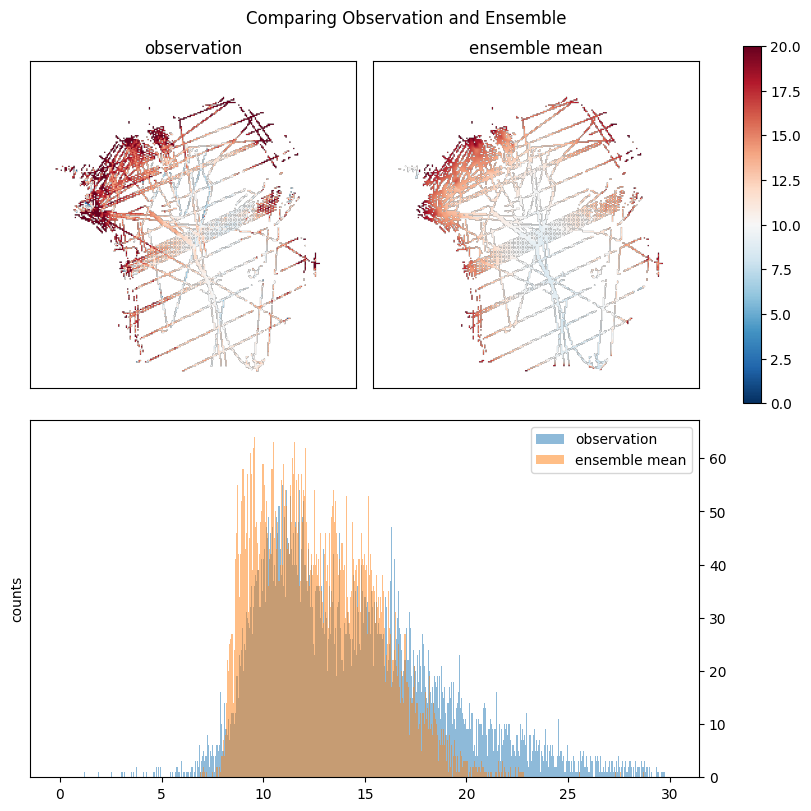

In [392]:
fig, ax = plt.subplot_mosaic([['A', 'B'],
                    ['C', 'C']],
                    figsize = (8, 8), layout = 'constrained')

vmin = 0
vmax = 20

im0 = ax['A'].imshow(attenu_obs.reshape(256, 256), vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax['A'].set_xticks([])
ax['A'].set_yticks([])
ax['A'].invert_yaxis()
ax['A'].set_title("observation")

attenu_fromEm_mean_per_pixel_flight_line = np.nanmean(attenu_fromEm, axis = 2)
attenu_fromEm_mean_per_pixel_flight_line[~radar_mask] = np.nan
im0 = ax['B'].imshow(attenu_fromEm_mean_per_pixel_flight_line, vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
cb0 = plt.colorbar(im0)
ax['B'].set_xticks([])
ax['B'].set_yticks([])
ax['B'].invert_yaxis()
ax['B'].set_title("ensemble mean")

bins = np.arange(0, 30, 0.05)
ax['C'].hist(attenu_obs.reshape(256, 256)[radar_mask], bins = bins, alpha = 0.5, label = 'observation');
ax['C'].hist(attenu_fromEm_mean_per_pixel_flight_line[radar_mask], bins = bins, alpha = 0.5, label = 'ensemble mean');
ax['C'].set_ylabel("counts")
ax['C'].legend()
ax['C'].yaxis.tick_right()

fig.suptitle("Comparing Observation and Ensemble")
fig.savefig("../figs/observation_vs_ensemble.svg")

In [393]:
attenu_pca.transform(attenu_obs_standard.reshape(1, -1))

array([[18.25351564, -3.89698071,  8.3177803 , -0.31966623,  6.01779069,
        -5.14077553, -1.90318386, -2.13665208, -0.40733124, -4.33305173,
        -7.77858534, -3.64612898,  9.63005476,  4.26638001,  7.01577515,
         0.43853844,  5.37985944, -0.18793717, -4.06709859,  0.94155987,
         9.68585858, -1.65746001,  0.67807366, -0.5756415 ,  0.37069391,
        -2.76487596,  3.61075253, -2.02157213,  1.24930659,  1.64496529,
        -0.0343626 ,  4.81419132]])

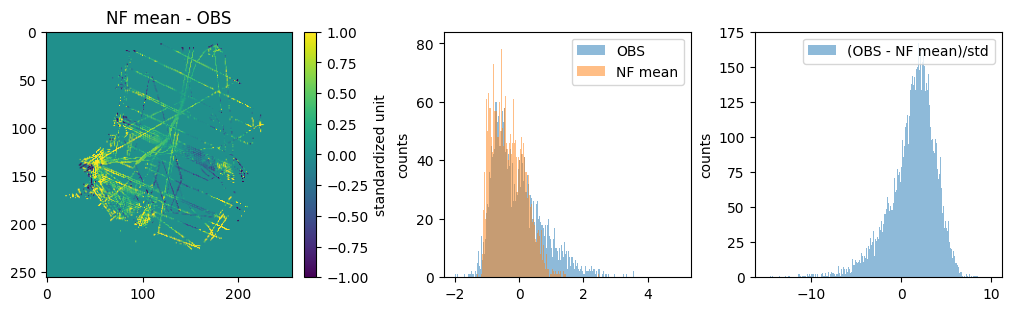

In [394]:
fig, ax = plt.subplots(1, 3, figsize = (10, 3), layout = 'constrained')

im0 = ax[0].imshow(attenu_obs_standard.reshape(256, 256) - np.mean(attenu_samples_nf, axis = 0), vmin = -1, vmax = 1)
cb0 = plt.colorbar(im0)
cb0.ax.set_ylabel("standardized unit")
ax[0].set_title("NF mean - OBS")

bins = np.arange(-2, 5, 0.01)
ax[1].hist(attenu_obs_standard[radar_mask.flatten()].flatten(), bins = bins, alpha = 0.5, label = 'OBS');
ax[1].hist(np.mean(attenu_samples_nf, axis = 0)[radar_mask].flatten(), bins = bins, alpha = 0.5, label = 'NF mean');
ax[1].set_ylabel("counts")
ax[1].legend()

bins = np.arange(-15, 10, 0.1)
ax[2].hist((attenu_obs_standard[radar_mask.flatten()].flatten() - np.mean(attenu_samples_nf, axis = 0)[radar_mask].flatten()) / std_attenu_obs_samples_standard[radar_mask.flatten()], bins = bins, alpha = 0.5, label = '(OBS - NF mean)/std');
ax[2].set_ylabel("counts")
ax[2].legend()

In [395]:
# custom_potential = hamiltonianMC_nf.custom_potential(model_nf, attenu_pca,
#                                                      attenu_obs_standard, std_attenu_obs_samples_standard * 2,
#                                                      radar_mask,
#                                                      verbose = True)

# x = {'x' : torch.tensor(attenu_obs_standard[np.newaxis, :] - 1).to(torch.float)}
# custom_potential.log_posterior(x)

# mean = np.zeros(3)
# cov = np.diag((np.ones(3) * 2) ** 2)

# from scipy.stats import multivariate_normal
# dist = multivariate_normal(mean, cov)
# dist.logpdf((1, 1, 1))

In [396]:
# import hamiltonianMC_nf
# custom_potential = hamiltonianMC_nf.custom_potential(model_nf, attenu_pca,
#                                                      attenu_obs_standard, std_attenu_obs_samples_standard_relaxed,
#                                                      radar_mask,
#                                                      verbose = True)

# custom_potential.log_posterior({'x': model_nf.sample(1)[0].detach()})

In [397]:
# uniform_std = 1
# x = model_nf.sample(1)[0]

# z = model_nf.inverse(x)
# z_image = torch.matmul(z, torch.tensor(attenu_pca.components_).float()) + torch.tensor(attenu_pca.mean_)
# #gaussian_z_image = torch.distributions.Normal(z_image, torch.full(attenu_obs.shape, 0.1))
# # print(z_image.shape)
# z_image = z_image.flatten()

# n = 7791
# log_likelihood = -0.5 * torch.sum(((1/(uniform_std ** 2)) * ((torch.tensor(attenu_obs_standard)[radar_mask.flatten()] - z_image[radar_mask.flatten()]) ** 2))) - (n / 2) * np.log(np.sqrt(((2 * np.pi * uniform_std))))

# print(x)
# print(log_likelihood)

# # plt.plot(attenu_obs_standard[radar_mask.flatten()] - z_image[radar_mask.flatten()].detach().numpy())

In [398]:
# import pyro.distributions as dist

# true_coefs = torch.tensor([1., 2., 3.])
# data = torch.randn(100, 3)
# dim = 3
# labels = dist.Bernoulli(logits=(true_coefs * data).sum(-1)).sample()

# def model(data):
#     coefs_mean = torch.zeros(dim)
#     coefs = pyro.sample('beta', dist.Normal(coefs_mean, torch.ones(3)))
#     y = pyro.sample('y', dist.Bernoulli(logits=(coefs * data).sum(-1)), obs=labels)
#     return y

# hmc_kernel = RandomWalkKernel(model, init_step_size=0.2)
# mcmc = MCMC(hmc_kernel, num_samples=200, warmup_steps=100)
# mcmc.run(data)
# mcmc.get_samples()['beta'].mean(0)  

In [ ]:
import pyro
from pyro.infer.mcmc import MCMC, HMC, NUTS, BlockMassMatrix
import hamiltonianMC_nf

std_attenu_obs_samples_standard_relaxed = std_attenu_obs_samples_standard.copy()
# std_attenu_obs_samples_standard_relaxed[std_attenu_obs_samples_standard_relaxed < 0.25] = 0.25
# std_attenu_obs_samples_standard_relaxed = std_attenu_obs_samples_standard * 10

custom_potential = hamiltonianMC_nf.custom_potential(model_nf, attenu_pca,
                                                     attenu_obs_standard, std_attenu_obs_samples_standard * 2,
                                                     radar_mask,
                                                     verbose = False)

# test_normal = torch.distributions.LowRankMultivariateNormal(torch.zeros(32), cov_factor = torch.ones(32)[:, torch.newaxis], cov_diag = torch.ones(32) * 1)

# custom_potential = hamiltonianMC_nf.custom_potential(model_nf, attenu_pca,
#                                                      attenu_pca.inverse_transform(attenu_latent_test_dataset[0][0].reshape(1, -1)).flatten(),
#                                                      std_attenu_obs_samples_standard,
#                                                      radar_mask,
#                                                      verbose = False)

# log_posterior_complied = torch.compile(custom_potential.log_posterior)

mcmc_kernel = NUTS(potential_fn = custom_potential.log_posterior)
#mcmc_kernel = HMC(potential_fn = custom_potential.log_posterior, step_size=1e-3)

num_chains = 4
num_samples = 1000 # samples per chain


if num_chains == 1:
    mcmc = MCMC(mcmc_kernel, warmup_steps=1000, num_samples=num_samples, num_chains = num_chains,
                            initial_params={"x": model_nf.sample(num_chains)[0].detach()}, disable_progbar=False)
elif num_chains > 1:
    mcmc = MCMC(mcmc_kernel, warmup_steps=1000, num_samples=num_samples, num_chains = num_chains,
                            initial_params={"x": model_nf.sample(num_chains)[0].detach().unsqueeze(1)})

# elif num_chains > 1:
#     mcmc = MCMC(mcmc_kernel, warmup_steps=100, num_samples=num_samples, num_chains = num_chains,
#                             initial_params={"x": model_nf.sample(num_chains)[0].detach().unsqueeze(1)})

mcmc.run(collect_warmup=False)
# .unsqueeze(1)
#
# attenu_samples_hmc_latent[i, :] = mcmc.get_samples()['x'][0][0]


# torch.save(attenu_samples_hmc_latent, './saved_data/attenu_samples_hmc_latent.pt')

Likelihood Gaussian rank = 7791


Warmup [1]:   0%|          | 0/2000 [00:00, ?it/s]

Warmup [2]:   0%|          | 0/2000 [00:00, ?it/s]

Warmup [3]:   0%|          | 0/2000 [00:00, ?it/s]

Warmup [4]:   0%|          | 0/2000 [00:00, ?it/s]

NF sample SE: 3082.03529202533
HMC intermediate sample SE: 2558.625399206373
HMC mean sample SE: 2556.2856856976528


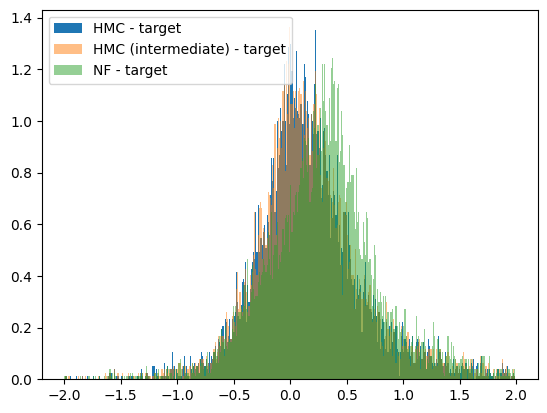

In [446]:
attenu_samples_hmc_latent = mcmc.get_samples()['x']
attenu_samples_hmc_latent = attenu_samples_hmc_latent[:, 0, :]

gaussian_negative_log_likelihood = torch.nn.GaussianNLLLoss(reduction = 'sum')

z_image_from_nf = np.nanmean(attenu_samples_nf, axis = 0).flatten()
z_image_from_hmc = attenu_pca.inverse_transform(torch.mean(attenu_samples_hmc_latent, axis = 0).reshape(1, -1))
z_image_from_hmc_intermediate = np.load('z_image.npz')['z_image']

input_nf = z_image_from_nf.flatten()[radar_mask.flatten()]
input_hmc = z_image_from_hmc.flatten()[radar_mask.flatten()]
input_hmc_intermediate = z_image_from_hmc_intermediate.flatten()[radar_mask.flatten()]
target = attenu_obs_standard.flatten()[radar_mask.flatten()]
var = std_attenu_obs_samples_standard[radar_mask.flatten()] ** 2
n = input_nf.shape[0]
uniform_std = 0.01
log_likelihood_nf = -0.5 * np.sum(((1/(uniform_std ** 2)) * ((input_nf - target) ** 2))) - (n / 2) * np.log(np.sqrt(((2 * np.pi * uniform_std))))
log_likelihood_hmc = -0.5 * np.sum(((1/(uniform_std ** 2)) * ((input_hmc - target) ** 2))) - (n / 2) * np.log(np.sqrt(((2 * np.pi * uniform_std))))
log_likelihood_hmc_intermediate = -0.5 * np.sum(((1/(uniform_std ** 2)) * ((input_hmc_intermediate - target) ** 2))) - (n / 2) * np.log(np.sqrt(((2 * np.pi * uniform_std))))


print(f"NF sample SE: {np.sum((input_nf - target) ** 2)}")
print(f"HMC intermediate sample SE: {np.sum((input_hmc - target) ** 2)}")
print(f"HMC mean sample SE: {np.sum((input_hmc_intermediate - target) ** 2)}")

bins = np.arange(-2, 2, 0.01)

plt.hist(target.flatten() - input_hmc.flatten(), bins = bins, label = "HMC - target", density = True);
plt.hist(target.flatten() - input_hmc_intermediate.flatten(), alpha = 0.5, bins = bins, label = "HMC (intermediate) - target", density = True);
plt.hist(target.flatten() - input_nf.flatten(), alpha = 0.5, bins = bins, label = "NF - target", density = True);
plt.legend()

Warmup:   7%|▋         | 2/30 [1:12:15, 2167.58s/it, step size=1.00e-05, acc. prob=1.000]


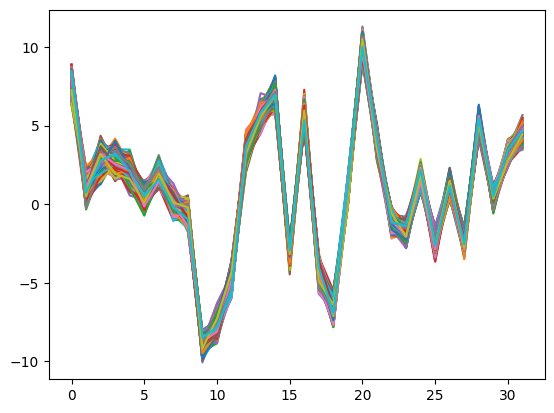

In [453]:
plt.plot(attenu_samples_hmc_latent.T);

In [418]:
# loss = torch.nn.GaussianNLLLoss(reduction = 'sum')

# input = attenu_pca.inverse_transform(model_nf.sample(num_chains)[0].detach().reshape(1, -1))
# target = attenu_obs_standard
# var = std_attenu_obs_samples_standard

# input = torch.tensor(input.flatten()[radar_mask.flatten()])
# target = torch.tensor(target[radar_mask.flatten()])
# var = torch.tensor(var[radar_mask.flatten()])

# output = loss(input, target, var)

# output

Text(0.5, 0, 'latent dimension')

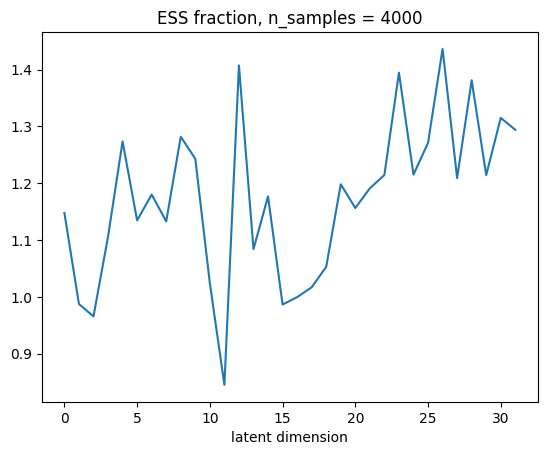

In [432]:
plt.plot((mcmc.diagnostics()['x']['n_eff']).flatten() / (num_samples * num_chains))
plt.title(f"ESS fraction, n_samples = {num_samples * num_chains}")
plt.xlabel("latent dimension")
# plt.ylim(bottom = 0)

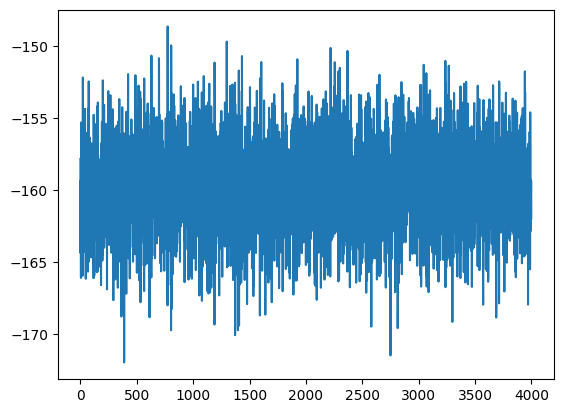

In [433]:
attenu_samples_hmc_latent_log_prob = model_nf.log_prob(torch.Tensor(attenu_samples_hmc_latent))
plt.plot(attenu_samples_hmc_latent_log_prob.detach().numpy())

Text(0.5, 1.0, 'posterior mean, latent space')

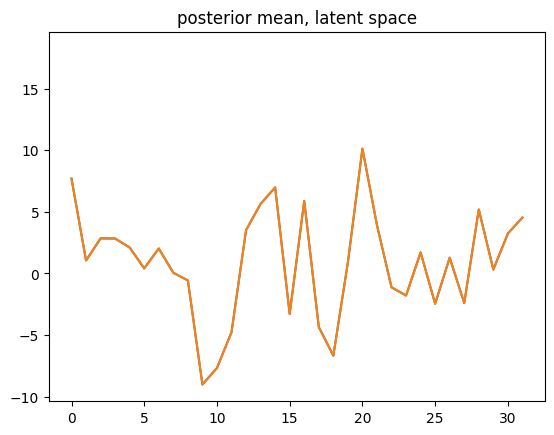

In [447]:
# attenu_samples_hmc_latent = np.load('../testing/attenu_samples_hmc_latent.npz', allow_pickle=True)['arr_0'].tolist()['attenu_samples_hmc_latent']

#attenu_samples_hmc_latent = np.load('../testing/attenu_samples_hmc_latent_2026-07-07 15:08:30.496297.npz')['attenu_samples_hmc_latent']
attenu_samples_hmc_latent_log_prob = model_nf.log_prob(torch.Tensor(attenu_samples_hmc_latent))

attenu_samples_hmc_latent = attenu_samples_hmc_latent.detach().numpy()
# attenu_samples_hmc_latent_prob = attenu_samples_hmc_latent_prob / torch.sum(attenu_samples_hmc_latent_prob)
# attenu_samples_hmc_latent_prob = attenu_samples_hmc_latent_prob.detach().numpy()
# attenu_samples_hmc_latent_prob = np.tile(attenu_samples_hmc_latent_prob[:, np.newaxis], (1, attenu_samples_hmc_latent.shape[1]))

attenu_samples_hmc_latent_post_mean = np.mean(attenu_samples_hmc_latent, axis = 0)
attenu_samples_hmc_post_mean = attenu_pca.inverse_transform(attenu_samples_hmc_latent_post_mean.reshape(1, -1)).reshape((256, 256))

attenu_samples_hmc_latent_post_mean = np.mean(attenu_samples_hmc_latent, axis = 0)
plt.plot(attenu_samples_hmc_latent_post_mean)
plt.plot(np.mean(attenu_samples_hmc_latent, axis = 0))

plt.plot(attenu_pca.transform(attenu_obs_standard.reshape(1, -1)), label = 'OBS', linestyle = 'dashed', c = 'red')
plt.title('posterior mean, latent space')


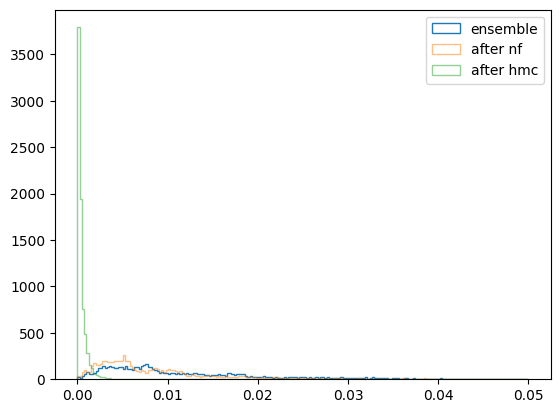

In [448]:
#attenu_samples_hmc_latent = mcmc.get_samples()['x']
#attenu_samples_hmc_latent = attenu_samples_hmc_latent[:, 0, :]
attenu_samples_hmc = attenu_pca.inverse_transform(attenu_samples_hmc_latent)
var_attenu_hmc = np.var(attenu_samples_hmc, axis = 0)
var_attenu_hmc = var_attenu_hmc.reshape((256, 256))

bins = np.linspace(0, 0.05, 200)

plt.hist(var_attenu_ensemble[radar_mask].flatten(), label = 'ensemble', bins = bins, density = False, histtype = 'step')
plt.hist(var_attenu_nf[radar_mask].flatten(), label = 'after nf', alpha = 0.5, bins = bins, density = False, histtype = 'step')
plt.hist(var_attenu_hmc[radar_mask].flatten(), label = 'after hmc', alpha = 0.5, bins = bins, density = False, histtype = 'step')
plt.legend()

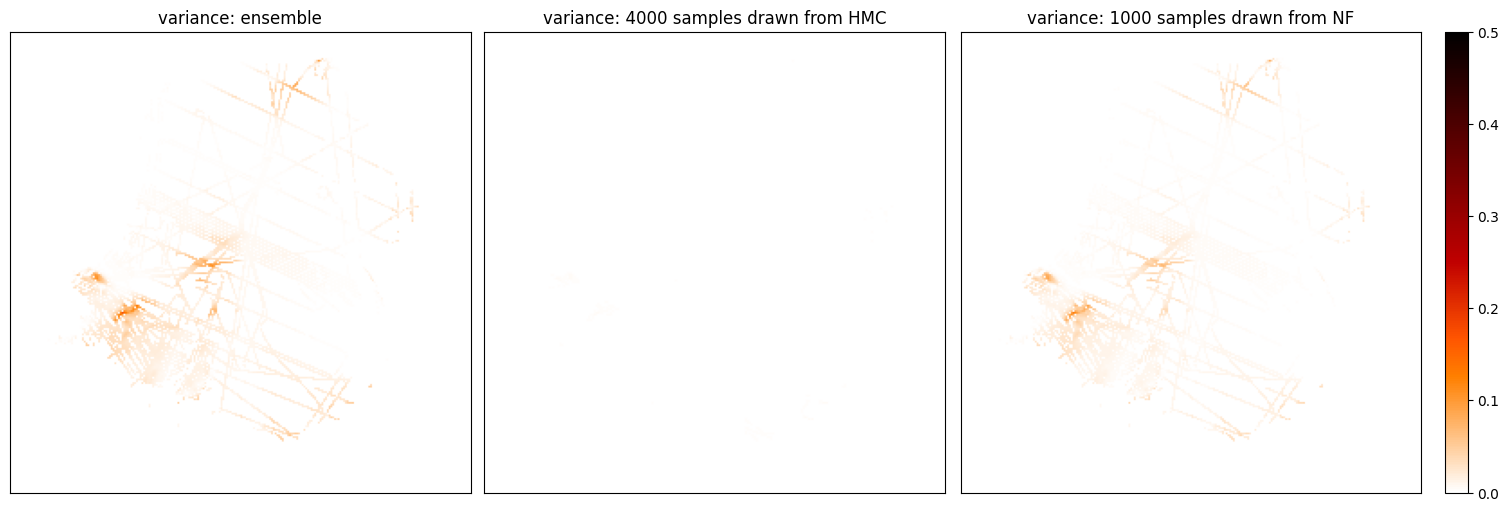

In [449]:
attenu_reconstruct = attenu_pca.inverse_transform(attenu_pca.transform(attenu_fromEm_standard[:, 0, :, :].reshape((-1, attenu_fromEm_standard.shape[2] ** 2))))
attenu_reconstruct_var = np.var(attenu_reconstruct, axis = 0).reshape((256, 256))

# attenu_hmc_samples = attenu_pca.inverse_transform(mcmc.get_samples()['x'][:, 0, :]).reshape((mcmc.get_samples()['x'][:, 0, :].shape[0], 256, 256))
var_attenu_samples_hmc = np.nanvar(attenu_samples_hmc, axis = 0).reshape(256, 256)

fig, ax = plt.subplots(1,3, figsize = (15, 5), layout="constrained")

vmin = 0
vmax = 0.5

im0 = ax[0].imshow(var_attenu_ensemble, vmin = vmin, vmax = vmax, cmap = 'gist_heat_r')
ax[0].set_title(f"variance: ensemble")
ax[0].set_xticks([])
ax[0].set_yticks([])

im1 = ax[1].imshow(var_attenu_hmc, vmin = vmin, vmax = vmax, cmap = 'gist_heat_r')
ax[1].set_title(f"variance: {attenu_samples_hmc.shape[0]} samples drawn from HMC")
ax[1].set_xticks([])
ax[1].set_yticks([])

im2 = ax[2].imshow(var_attenu_nf, vmin = vmin, vmax = vmax, cmap = 'gist_heat_r')
ax[2].set_title(f"variance: {attenu_samples_nf.shape[0]} samples drawn from NF")
ax[2].set_xticks([])
ax[2].set_yticks([])
plt.colorbar(im2)

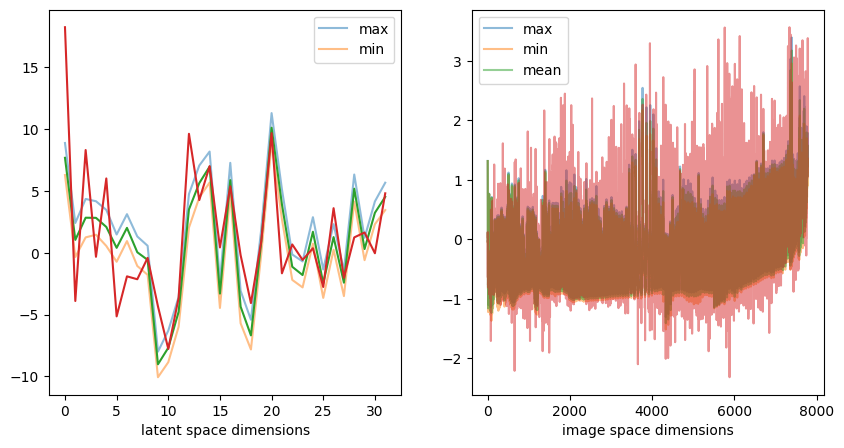

In [450]:
fig, ax = plt.subplots(1, 2, figsize = (10, 5))

attenu_obs_latent = attenu_obs_standard.copy()
attenu_obs_latent[np.isnan(attenu_obs_latent)] = 0
attenu_obs_latent = attenu_pca.transform(attenu_obs_latent.reshape(1, -1))


max_attenu_samples_hmc_latent = np.max(attenu_samples_hmc_latent, axis = 0)
min_attenu_samples_hmc_latent = np.min(attenu_samples_hmc_latent, axis = 0)
ax[0].plot(max_attenu_samples_hmc_latent, alpha = 0.5, label = 'max')
ax[0].plot(min_attenu_samples_hmc_latent, alpha = 0.5, label = 'min')
ax[0].plot(attenu_samples_hmc_latent_post_mean)
ax[0].plot(attenu_obs_latent.flatten())
ax[0].set_xlabel('latent space dimensions')
ax[0].legend()

max_attenu_samples_hmc = np.max(attenu_samples_hmc, axis = 0)
min_attenu_samples_hmc = np.min(attenu_samples_hmc, axis = 0)
ax[1].plot(max_attenu_samples_hmc.reshape(256, 256)[radar_mask], alpha = 0.5, label = 'max')
ax[1].plot(min_attenu_samples_hmc.reshape(256, 256)[radar_mask], alpha = 0.5, label = 'min')
ax[1].plot(attenu_samples_hmc_post_mean[radar_mask], alpha = 0.5, label = 'mean')
ax[1].plot(attenu_obs_standard.reshape(256, 256)[radar_mask].flatten(), alpha = 0.5)
ax[1].set_xlabel('image space dimensions')
ax[1].legend()

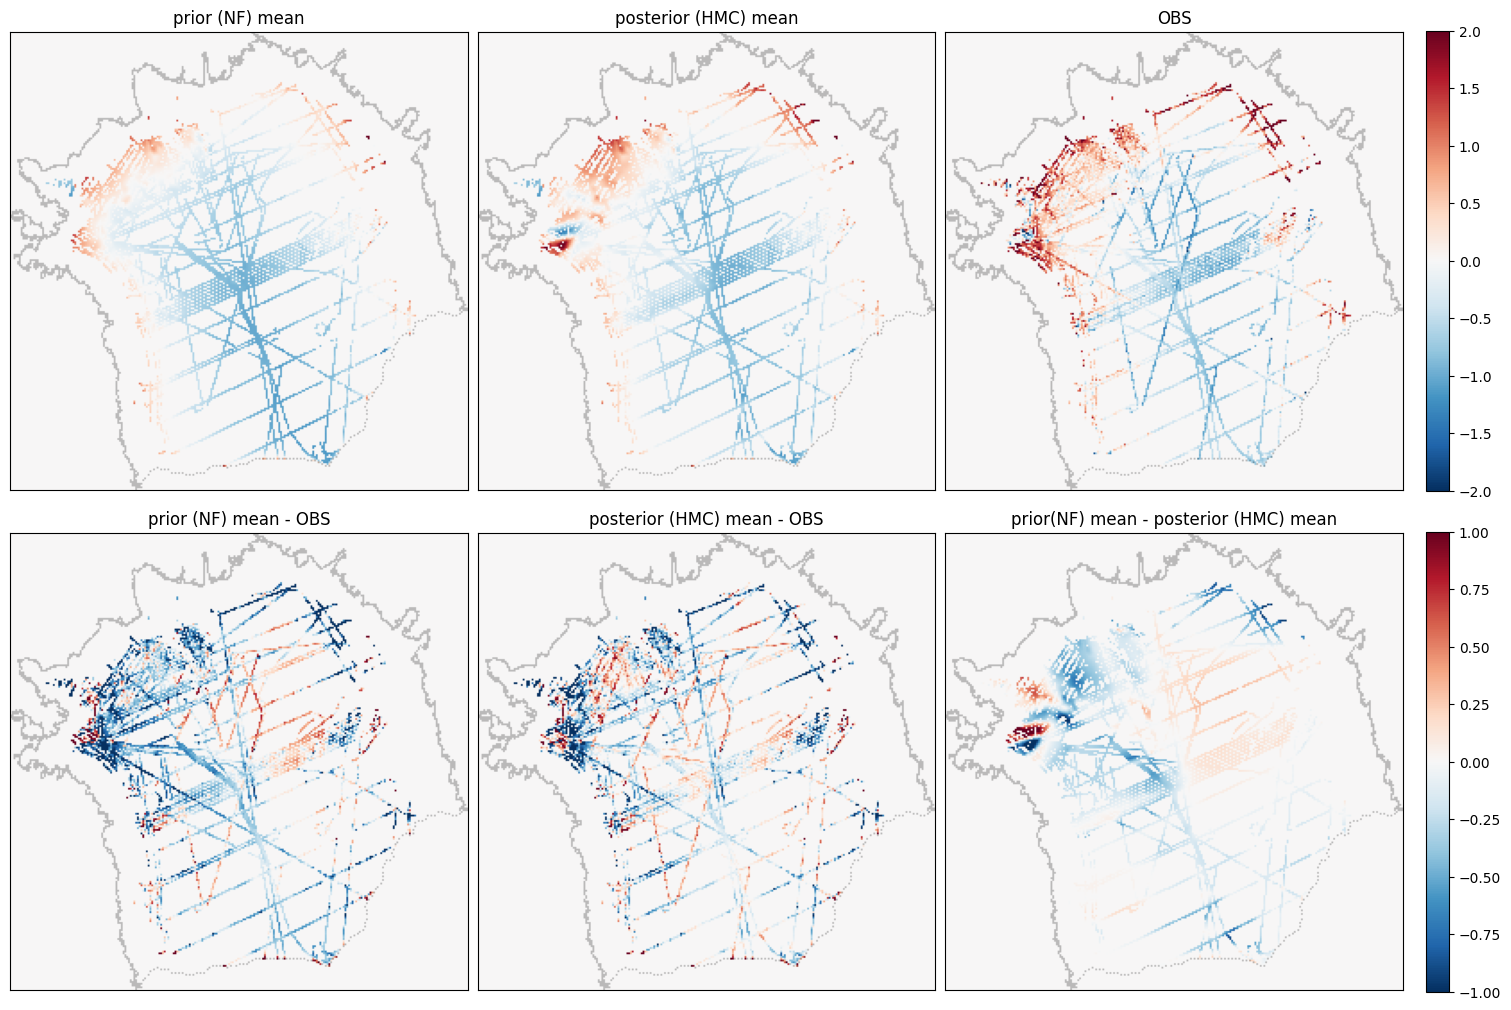

In [451]:
fig, ax = plt.subplots(2, 3, figsize = (15, 10), layout = 'constrained')

vmin = -2
vmax = 2

im00 = ax[0, 0].imshow(np.mean(attenu_samples_nf, axis = 0), vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[0, 0].set_title(f"prior (NF) mean")
ax[0, 0].set_xticks([])
ax[0, 0].set_yticks([])
ax[0, 0].imshow(boundary, cmap = 'gray', alpha = 0.25)
ax[0, 0].invert_yaxis()

im01 = ax[0, 1].imshow(attenu_samples_hmc_post_mean, vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[0, 1].set_title("posterior (HMC) mean")
ax[0, 1].set_xticks([])
ax[0, 1].set_yticks([])
ax[0, 1].imshow(boundary, cmap = 'gray', alpha = 0.25)
ax[0, 1].invert_yaxis()

im02 = ax[0, 2].imshow(attenu_obs_standard.reshape(256, 256), vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[0, 2].set_title("OBS")
ax[0, 2].set_xticks([])
ax[0, 2].set_yticks([])
ax[0, 2].imshow(boundary, cmap = 'gray', alpha = 0.25)
ax[0, 2].invert_yaxis()
plt.colorbar(im02)


vmin = -1
vmax = 1

im10 = ax[1, 0].imshow(np.mean(attenu_samples_nf, axis = 0) - attenu_obs_standard.reshape(256, 256), vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[1, 0].set_title("prior (NF) mean - OBS")
ax[1, 0].set_xticks([])
ax[1, 0].set_yticks([])
ax[1, 0].imshow(boundary, cmap = 'gray', alpha = 0.25)
ax[1, 0].invert_yaxis()

im11 = ax[1, 1].imshow(attenu_samples_hmc_post_mean - attenu_obs_standard.reshape(256, 256), vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[1, 1].set_title("posterior (HMC) mean - OBS")
ax[1, 1].set_xticks([])
ax[1, 1].set_yticks([])
ax[1, 1].imshow(boundary, cmap = 'gray', alpha = 0.25)
ax[1, 1].invert_yaxis()

im12 = ax[1, 2].imshow(np.mean(attenu_samples_nf, axis = 0) - attenu_samples_hmc_post_mean, vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[1, 2].set_title("prior(NF) mean - posterior (HMC) mean")
ax[1, 2].set_xticks([])
ax[1, 2].set_yticks([])
ax[1, 2].imshow(boundary, cmap = 'gray', alpha = 0.25)
ax[1, 2].invert_yaxis()
plt.colorbar(im12)

# fig.tight_layout()

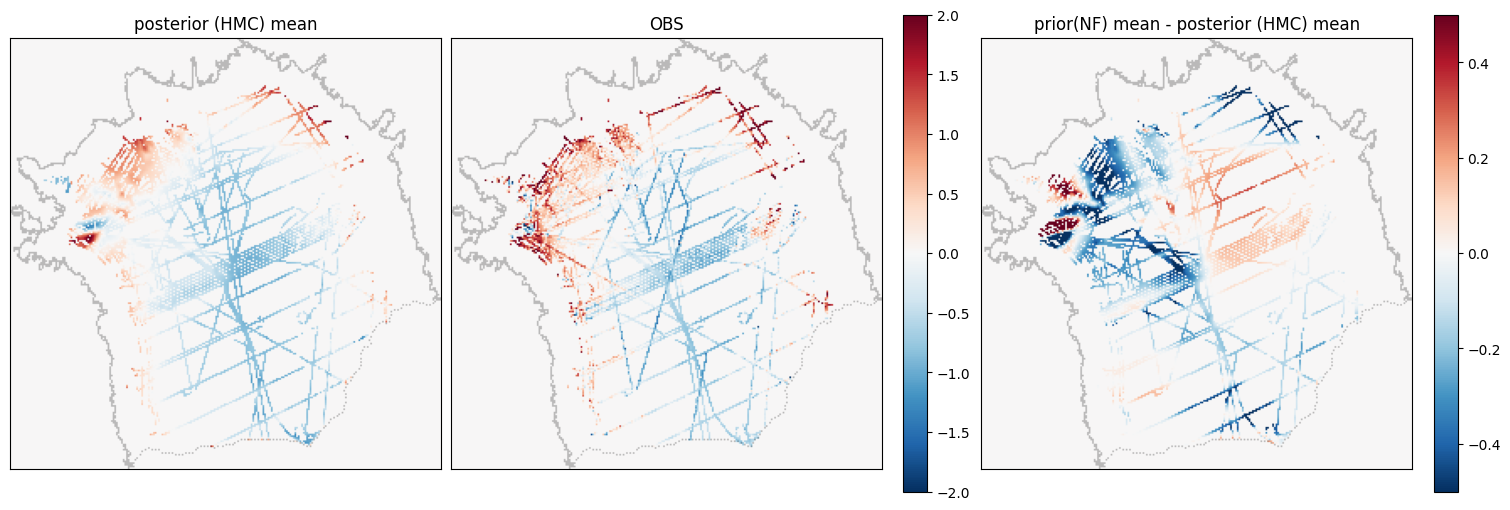

In [452]:
fig, ax = plt.subplots(1, 3, figsize = (15, 5), layout = 'constrained')

vmin = -2
vmax = 2

im0 = ax[0].imshow(attenu_samples_hmc_post_mean, vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[0].set_title("posterior (HMC) mean")
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].imshow(boundary, cmap = 'gray', alpha = 0.25)
ax[0].invert_yaxis()

im1 = ax[1].imshow(attenu_obs_standard.reshape(256, 256), vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[1].set_title("OBS")
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].imshow(boundary, cmap = 'gray', alpha = 0.25)
ax[1].invert_yaxis()
plt.colorbar(im1)

vmin = -0.5
vmax = 0.5

im2 = ax[2].imshow(np.mean(attenu_samples_nf, axis = 0) - attenu_samples_hmc_post_mean, vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[2].set_title("prior(NF) mean - posterior (HMC) mean")
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].imshow(boundary, cmap = 'gray', alpha = 0.25)
ax[2].invert_yaxis()
plt.colorbar(im2)

fig.savefig('../figs/nf_vs_hmc_vs_obs.svg')

# fig.tight_layout()

## Gradient Descent

In [371]:
model_nf.forward(torch.rand(1, 32))

tensor([[ 1.4299,  2.0798,  1.5499,  0.6454,  1.3804,  0.4766,  0.7502,  0.1290,
          1.0242,  0.1323,  1.3932,  0.2098,  0.5451, -0.0619,  0.1427,  0.5541,
          1.0338,  0.9066,  0.2026,  0.3449,  0.9022, -0.0600,  0.1885,  0.4027,
          0.0021,  0.4357,  0.7105,  0.1711,  0.2716,  0.8355,  0.3927,  0.3429]],
       grad_fn=<IndexBackward0>)

In [388]:
import hamiltonianMC_nf

attenu_samples_nf_latent_unoptim = attenu_samples_nf_latent[0:100].clone().detach().requires_grad_(True)
attenu_samples_nf_latent_optim = attenu_samples_nf_latent_unoptim.clone().detach().requires_grad_(True)

# custom_potential = hamiltonianMC_nf.custom_potential(model_nf, attenu_pca,
#                                                      attenu_pca.inverse_transform(attenu_latent_test_dataset[0][0].reshape(1, -1)).flatten(),
#                                                      std_attenu_obs_samples_standard,
#                                                      radar_mask,
#                                                      verbose = False)

custom_potential = hamiltonianMC_nf.custom_potential(model_nf, attenu_pca,
                                                     attenu_obs_standard,
                                                     std_attenu_obs_samples_standard * 2,
                                                     radar_mask,
                                                     verbose = False)


max_epoch = 100
optimizer = torch.optim.Adam({attenu_samples_nf_latent_optim}, lr=1)
epoch_loss = []

for epoch in range(max_epoch):
    optimizer.zero_grad()

    start = torch.Event(enable_timing=True)
    end = torch.Event(enable_timing=True)
    start.record()

    loss = custom_potential.log_posterior({'x': attenu_samples_nf_latent_optim})

    # Do backprop and optimizer step
    if ~(torch.isnan(loss) | torch.isinf(loss)):
        loss.backward()
        optimizer.step()
        epoch_loss = np.append(epoch_loss, loss.item())
        
    end.record()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    print(f"Epoch [{epoch + 1}/{max_epoch}], loss: {epoch_loss[epoch]:.4f}, time elapsed = {start.elapsed_time(end)/1000:.2f} s")

# plt.plot(epoch_loss)

Likelihood Gaussian rank = 7791
Epoch [1/100], loss: 1167030.2500, time elapsed = 0.18 s
Epoch [2/100], loss: 1047538.0625, time elapsed = 0.20 s
Epoch [3/100], loss: 964340.1875, time elapsed = 0.19 s
Epoch [4/100], loss: 909149.2500, time elapsed = 0.20 s
Epoch [5/100], loss: 873572.3125, time elapsed = 0.19 s
Epoch [6/100], loss: 851266.9375, time elapsed = 0.19 s
Epoch [7/100], loss: 837681.4375, time elapsed = 0.19 s
Epoch [8/100], loss: 829677.3125, time elapsed = 0.19 s
Epoch [9/100], loss: 825143.5625, time elapsed = 0.19 s
Epoch [10/100], loss: 822718.7500, time elapsed = 0.19 s
Epoch [11/100], loss: 821516.5625, time elapsed = 0.19 s
Epoch [12/100], loss: 820931.0000, time elapsed = 0.18 s
Epoch [13/100], loss: 820516.1875, time elapsed = 0.17 s
Epoch [14/100], loss: 819934.8125, time elapsed = 0.19 s
Epoch [15/100], loss: 818965.0625, time elapsed = 0.19 s
Epoch [16/100], loss: 817531.2500, time elapsed = 0.19 s
Epoch [17/100], loss: 815693.0000, time elapsed = 0.18 s
Epoch 

Text(0.5, 1.0, 'posterior prob')

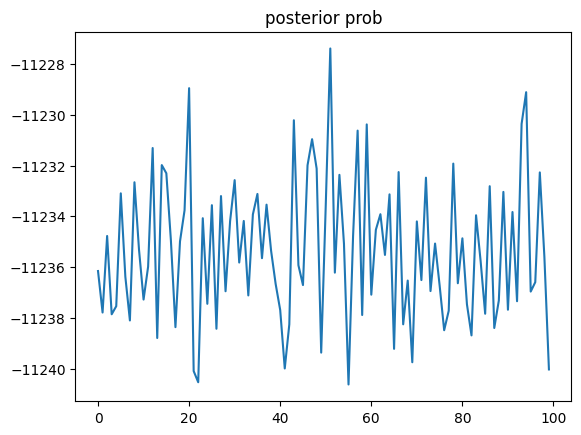

In [389]:
log_p_posterior = np.full(attenu_samples_nf_latent_optim.shape[0], np.nan)

for i in range(attenu_samples_nf_latent_optim.shape[0]):
    x = attenu_samples_nf_latent_optim[i:i+1, :]

    log_p_prior_sample = model_nf.log_prob(x)

    z = model_nf.inverse(x)
    z_image = torch.matmul(z, torch.tensor(attenu_pca.components_).float()) + torch.tensor(attenu_pca.mean_)
    #gaussian_z_image = torch.distributions.Normal(z_image, torch.full(attenu_obs.shape, 0.1))
    # print(z_image.shape)
    z_image = z_image.flatten()
    # analytical gaussian
    log_likelihood_sample = -0.5 * torch.sum((1/((torch.tensor(std_attenu_obs_samples_standard * 2))[radar_mask.flatten()] ** 2)) * ((torch.tensor(attenu_obs_standard)[radar_mask.flatten()] - z_image[radar_mask.flatten()]) ** 2)) #- np.log(np.sqrt(((2 * np.pi) ** n) * (torch.prod(self.attenu_obs_std ** 2))))

    log_p_posterior[i] = log_p_prior_sample + log_likelihood_sample

plt.plot(log_p_posterior)
plt.title("posterior prob")

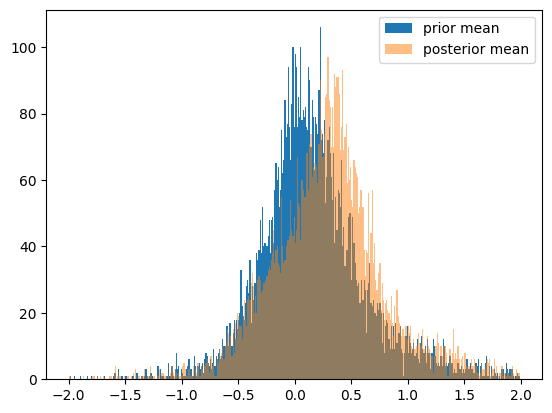

In [390]:
attenu_samples_nf_image_optim = attenu_pca.inverse_transform(attenu_samples_nf_latent_optim.detach().numpy()).reshape(attenu_samples_nf_latent_optim.shape[0], 256, 256)
attenu_samples_nf_image_optim_mean = np.mean(attenu_samples_nf_image_optim, axis = 0)
attenu_samples_nf_image_optim_var = np.var(attenu_samples_nf_image_optim, axis = 0)

attenu_samples_nf_image_unoptim = attenu_pca.inverse_transform(attenu_samples_nf_latent_unoptim.detach().numpy()).reshape(attenu_samples_nf_latent_optim.shape[0], 256, 256)
attenu_samples_nf_image_unoptim_mean = np.mean(attenu_samples_nf_image_unoptim, axis = 0)
attenu_samples_nf_image_unoptim_var = np.var(attenu_samples_nf_image_unoptim, axis = 0)

bins = np.arange(-2, 2, 0.01)
im1 = plt.hist((attenu_obs_standard.reshape(256, 256)[radar_mask] - attenu_samples_nf_image_optim_mean[radar_mask]).flatten(), bins, label = 'prior mean')
im1 = plt.hist((attenu_obs_standard.reshape(256, 256)[radar_mask] - attenu_samples_nf_image_unoptim_mean[radar_mask]).flatten(), bins, alpha = 0.5, label = 'posterior mean')
plt.legend()

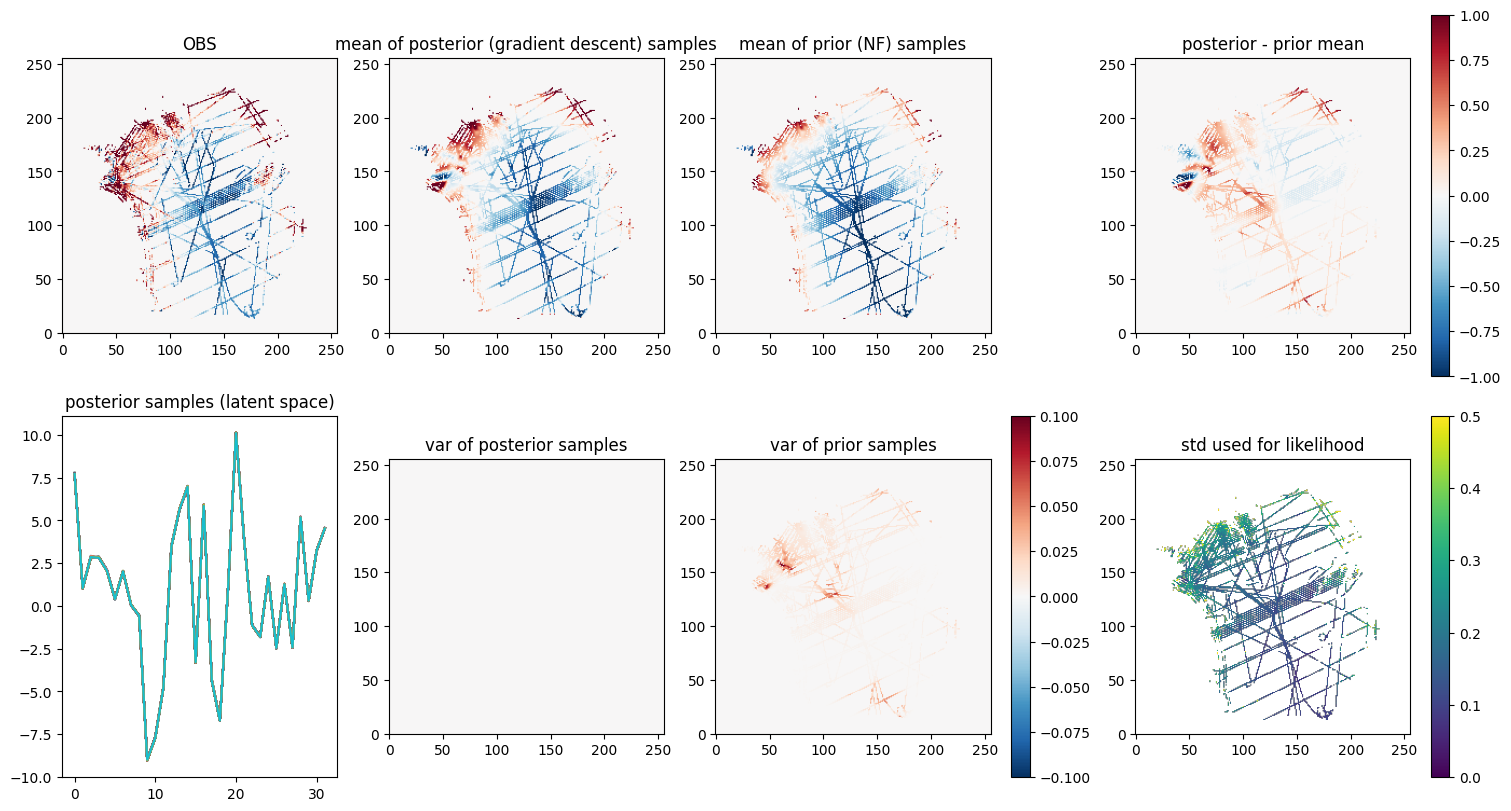

In [391]:
fig, ax = plt.subplots(2, 4, figsize = (15, 8), layout = "constrained")

vmin = -1
vmax = 1

ax[0, 0].imshow(attenu_obs_standard.reshape(256, 256), vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[0, 0].invert_yaxis()
ax[0, 0].set_title("OBS")

ax[0, 1].imshow(attenu_samples_nf_image_optim_mean, vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[0, 1].invert_yaxis()
ax[0, 1].set_title("mean of posterior (gradient descent) samples")

ax[0, 2].imshow(attenu_samples_nf_image_unoptim_mean, vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[0, 2].invert_yaxis()
ax[0, 2].set_title("mean of prior (NF) samples")

im03 = ax[0, 3].imshow(attenu_samples_nf_image_optim_mean - attenu_samples_nf_image_unoptim_mean, vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[0, 3].invert_yaxis()
ax[0, 3].set_title("posterior - prior mean")
plt.colorbar(im03)

ax[1, 0].plot(attenu_samples_nf_latent_optim.detach().numpy().T);
ax[1, 0].set_title("posterior samples (latent space)")

vmin = -0.1
vmax = 0.1
ax[1, 1].imshow(attenu_samples_nf_image_optim_var, vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[1, 1].invert_yaxis()
ax[1, 1].set_title("var of posterior samples")

im12 = ax[1, 2].imshow(attenu_samples_nf_image_unoptim_var, vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
ax[1, 2].invert_yaxis()
ax[1, 2].set_title("var of prior samples")
plt.colorbar(im12)

im13 = ax[1, 3].imshow(std_attenu_obs_samples_standard.reshape(256, 256), vmin = 0, vmax = 0.5)
ax[1, 3].invert_yaxis()
ax[1, 3].set_title("std used for likelihood")
plt.colorbar(im13)

# Validation

#### for training, only keep first 5 componenets, replace remaining components with some constant

#### posterior samples should have no information beyond the 5th component, i.e. remaining dimensions should be filled with that constant

In [484]:
n_components_keep = 8

Text(0.5, 1.0, 'after cutoff')

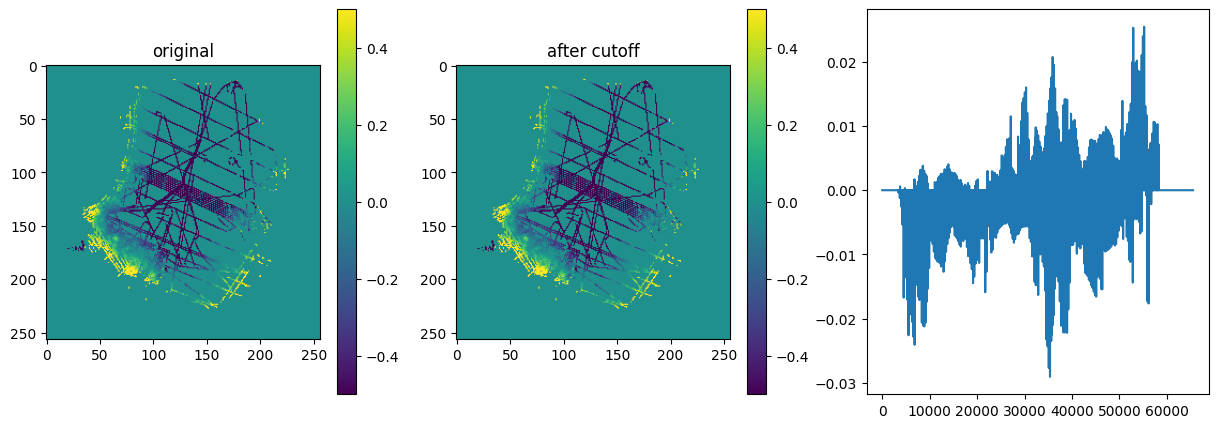

In [485]:
# load data: attenuation rate in PCA latent space
#num_epochs = 50
batch_size = 32

# attenu_fromEm_standard = np.load('attenu_fromEm_standard.npz')['attenu_fromEm_standard']
# attenu_pca = joblib.load('./saved_data/attenu_pca.pkl')
#attenu_pca = sklearn.decomposition.PCA(n_components = 32)
#attenu_pca.fit(attenu_fromEm_standard[:, 0, :, :].reshape((-1, attenu_fromEm_standard.shape[2] ** 2)))
# attenu_pca = joblib.load('../testing/attenu_pca2026-07-06 10:09:51.669799.pkl')
# attenu_latent = attenu_pca.transform(attenu_fromEm_standard[:, 0, :, :].reshape((-1, attenu_fromEm_standard.shape[2] ** 2)))
# attenu_latent = torch.tensor(attenu_latent).float()

attenu_latent_cutoff = attenu_latent.detach().clone()
attenu_latent_cutoff[:, n_components_keep:] = torch.full(attenu_latent[:, n_components_keep:].shape, 0.1)

fig, ax = plt.subplots(1,3, figsize = (15, 5))

vmin = -0.5
vmax = 0.5

attenu_mean_original = np.mean(attenu_pca.inverse_transform(attenu_latent).reshape(attenu_pca.inverse_transform(attenu_latent).shape[0], int(np.sqrt(attenu_pca.inverse_transform(attenu_latent).shape[1])), int(np.sqrt(attenu_pca.inverse_transform(attenu_latent).shape[1]))), axis = 0)
attenu_mean_cutoff = np.mean(attenu_pca.inverse_transform(attenu_latent_cutoff).reshape(attenu_pca.inverse_transform(attenu_latent_cutoff).shape[0], int(np.sqrt(attenu_pca.inverse_transform(attenu_latent_cutoff).shape[1])), int(np.sqrt(attenu_pca.inverse_transform(attenu_latent_cutoff).shape[1]))), axis = 0)

im0 = ax[0].imshow(attenu_mean_original, vmin = vmin, vmax = vmax)
im1 = ax[1].imshow(attenu_mean_cutoff, vmin = vmin, vmax = vmax)
im2 = ax[2].plot(attenu_mean_original.flatten() - attenu_mean_cutoff.flatten())
plt.colorbar(im0)
plt.colorbar(im1)

ax[0].set_title("original")
ax[1].set_title(f"after cutoff")

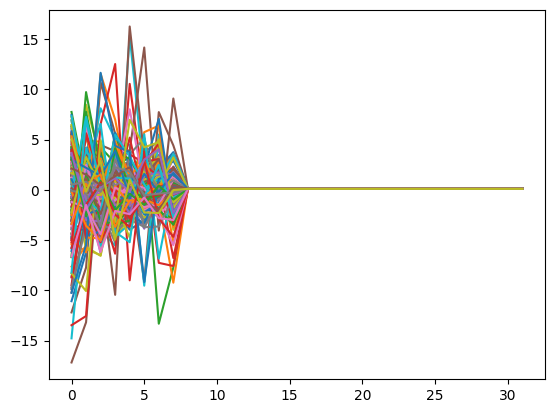

In [486]:
plt.plot(attenu_latent_cutoff.T);

In [487]:
import joblib
batch_size = 64
# train val test split
attenu_latent_cutoff_dataset = TensorDataset(attenu_latent_cutoff, attenu_latent_cutoff)
#attenu_latent_cutoff_dataset = TensorDataset(attenu_latent_cutoff_standard, attenu_lat/ent_noisy_standard)

train_size = (int(0.7 * len(attenu_latent_cutoff_dataset)) // batch_size) * batch_size
val_size = int((len(attenu_latent_cutoff_dataset) - train_size)/2)
test_size = int(len(attenu_latent_cutoff_dataset) - train_size - val_size)

generator = torch.Generator().manual_seed(42)
attenu_latent_cutoff_train_dataset, attenu_latent_cutoff_val_dataset, attenu_latent_cutoff_test_dataset = random_split(attenu_latent_cutoff_dataset, [train_size, val_size, test_size], generator=generator)

attenu_latent_cutoff_train_dataloader = DataLoader(attenu_latent_cutoff_train_dataset, batch_size = batch_size, shuffle = 1)
attenu_latent_cutoff_val_dataloader = DataLoader(attenu_latent_cutoff_val_dataset, batch_size = batch_size, shuffle = 1)
attenu_latent_cutoff_test_dataloader = DataLoader(attenu_latent_cutoff_test_dataset, batch_size = batch_size, shuffle = 1)

In [491]:
# Set up model_nf
in_features = int(attenu_latent.shape[1]/2)

# Define list of flows
num_layers = 8
flows = []
for i in range(num_layers):
    param_map = nf.nets.MLP([in_features, 64, 256, 64, in_features * 2], init_zeros=True, leaky = 0.01)
    # Add flow layer
    flows.append(nf.flows.AffineCouplingBlock(param_map))
    # Swap dimensions
    flows.append(nf.flows.Permute(in_features * 2, mode='shuffle'))

# base distribution is a Gaussian with num of dimension same as training data
base = nf.distributions.base.DiagGaussian(in_features * 2)

# Construct flow model_nf
model_nf_validation = nf.NormalizingFlow(base, flows)

model_nf_validation

NormalizingFlow(
  (q0): DiagGaussian()
  (flows): ModuleList(
    (0): AffineCouplingBlock(
      (flows): ModuleList(
        (0): Split()
        (1): AffineCoupling(
          (param_map): MLP(
            (net): Sequential(
              (0): Linear(in_features=16, out_features=64, bias=True)
              (1): LeakyReLU(negative_slope=0.01)
              (2): Linear(in_features=64, out_features=256, bias=True)
              (3): LeakyReLU(negative_slope=0.01)
              (4): Linear(in_features=256, out_features=64, bias=True)
              (5): LeakyReLU(negative_slope=0.01)
              (6): Linear(in_features=64, out_features=32, bias=True)
            )
          )
        )
        (2): Merge()
      )
    )
    (1): Permute()
    (2): AffineCouplingBlock(
      (flows): ModuleList(
        (0): Split()
        (1): AffineCoupling(
          (param_map): MLP(
            (net): Sequential(
              (0): Linear(in_features=16, out_features=64, bias=True)
             

In [492]:
# using linear regression to prevent overfitting
window_size = 100

reg = sklearn.linear_model.LinearRegression()
window = np.arange(window_size).reshape(-1, 1)

# Train model_nf_validation
max_epoch = 6000
early_stopping_threshold = 1e-3

epoch_loss = np.array([])
epoch_loss_val = np.array([])

#optimizer = torch.optim.Adam(model_nf_validation.parameters(), lr=1e-5, weight_decay=1e-5)
optimizer = torch.optim.AdamW(model_nf_validation.parameters(), lr=1e-6)
model_nf_validation.train()

try:
    for epoch in range(max_epoch):
        optimizer.zero_grad()

        start = torch.Event(enable_timing=True)
        end = torch.Event(enable_timing=True)
        start.record()

        running_loss = 0.0
        running_loss_val = 0.0

        for train_batch, _ in attenu_latent_cutoff_train_dataloader:
            # Compute loss
            loss = model_nf_validation.forward_kld(train_batch)
            
            # Do backprop and optimizer step
            if ~(torch.isnan(loss) | torch.isinf(loss)):
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * train_batch.size(0)

        for val_batch, _ in attenu_latent_cutoff_val_dataloader:
            # Compute loss
            val_loss = model_nf_validation.forward_kld(val_batch)

            if ~(torch.isnan(val_loss) | torch.isinf(val_loss)):
                val_loss.backward()
                running_loss_val += val_loss.item() * val_batch.size(0)
                
        epoch_loss = np.append(epoch_loss, running_loss / len(attenu_latent_train_dataloader.dataset))
        epoch_loss_val = np.append(epoch_loss_val, running_loss_val / len(attenu_latent_val_dataloader.dataset))

        if epoch >= window.shape[0]:
            #print(epoch_loss[-window_size:])
            #print(epoch_loss_val[-window_size:])
            reg.fit(window, epoch_loss[-window_size:])
            epoch_loss_slope = reg.coef_


            reg.fit(window, epoch_loss_val[-window_size:])
            epoch_loss_val_slope = reg.coef_
            
            print(f"Epoch validation loss slope: {epoch_loss_val_slope}")
            print(f"Epoch loss slope: {epoch_loss_slope}")

            if (epoch_loss_slope > -early_stopping_threshold) or (epoch_loss_val_slope > -early_stopping_threshold):
                print("Early stopping")
                break

        end.record()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        print(f"Epoch [{epoch + 1}/{max_epoch}], loss: {epoch_loss[epoch]:.4f}, validation loss: {epoch_loss_val[epoch]:.4f}, time elapsed = {start.elapsed_time(end)/1000:.2f} s")
        
    torch.save(model_nf_validation.state_dict(), f'./saved_data/validation_realNVP.pth')
    np.savez(f'./saved_data/validation_realNVP_loss.npz',epoch_loss = epoch_loss, epoch_loss_val = epoch_loss_val) 

except KeyboardInterrupt:
    torch.save(model_nf_validation.state_dict(), f'./saved_data/validation_realNVP.pth')
    np.savez(f'./saved_data/validation_realNVP_loss.npz',epoch_loss = epoch_loss, epoch_loss_val = epoch_loss_val)


Epoch [1/6000], loss: 61.2118, validation loss: 74.0146, time elapsed = 0.01 s
Epoch [2/6000], loss: 61.2074, validation loss: 74.0107, time elapsed = 0.01 s
Epoch [3/6000], loss: 61.2024, validation loss: 74.0070, time elapsed = 0.01 s
Epoch [4/6000], loss: 61.1984, validation loss: 74.0032, time elapsed = 0.01 s
Epoch [5/6000], loss: 61.1943, validation loss: 73.9995, time elapsed = 0.01 s
Epoch [6/6000], loss: 61.1899, validation loss: 73.9957, time elapsed = 0.01 s
Epoch [7/6000], loss: 61.1854, validation loss: 73.9919, time elapsed = 0.01 s
Epoch [8/6000], loss: 61.1812, validation loss: 73.9882, time elapsed = 0.01 s
Epoch [9/6000], loss: 61.1772, validation loss: 73.9844, time elapsed = 0.01 s
Epoch [10/6000], loss: 61.1727, validation loss: 73.9807, time elapsed = 0.01 s
Epoch [11/6000], loss: 61.1689, validation loss: 73.9769, time elapsed = 0.01 s
Epoch [12/6000], loss: 61.1647, validation loss: 73.9731, time elapsed = 0.01 s
Epoch [13/6000], loss: 61.1599, validation loss: 

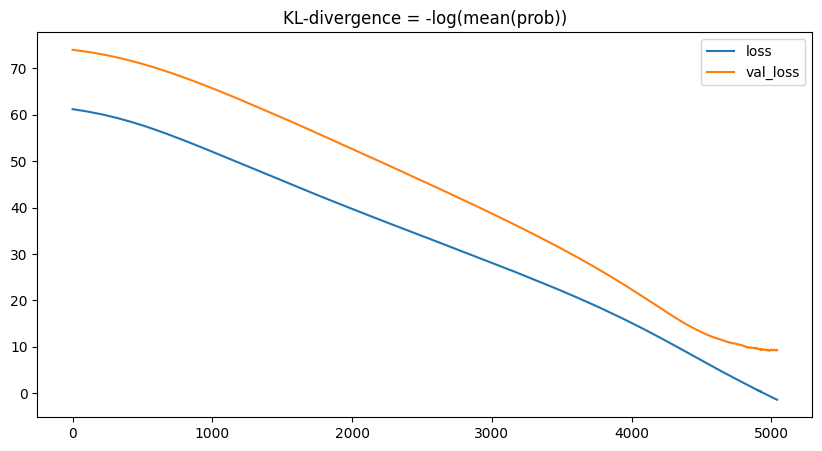

In [493]:
# Plot loss
#epoch_loss = np.load('../testing/realNVP_2026-06-22 15:29:54.090759_loss.npz')['epoch_loss']
#epoch_loss_val = np.load('../testing/realNVP_2026-06-22 15:29:54.090759_loss.npz')['epoch_loss_val']

plt.figure(figsize=(10, 5))
plt.plot(epoch_loss[0:-1], label='loss')
plt.plot(epoch_loss_val[0:-1], label='val_loss')

# plt.yscale("log")

plt.title('KL-divergence = -log(mean(prob))')
plt.legend()
plt.show()


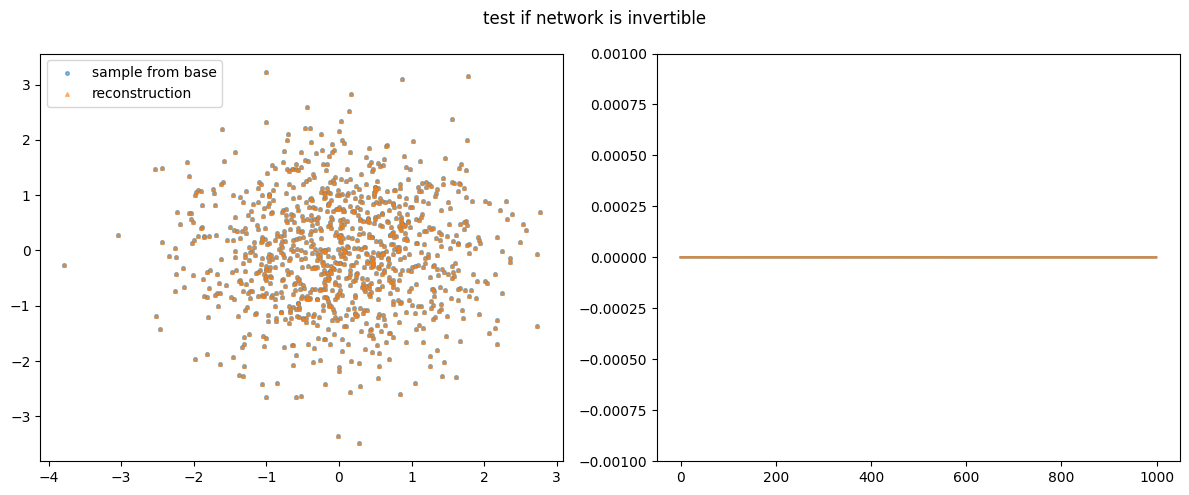

In [495]:
# model_nf_validation.load_state_dict(torch.load('../notebooks/saved_data/realNVP_32_5e-05_128_64_2.pth', weights_only=True))
model_nf_validation.eval()

x0 = base.sample(1000)
x1_from_x0 = model_nf_validation.forward(x0)
x1 = model_nf_validation.sample(1000)[0]
x0_from_x1_from_x0 = model_nf_validation.inverse(x1_from_x0)

x0 = x0.detach().numpy()
x1 = x1.detach().numpy()
x1_from_x0 = x1_from_x0.detach().numpy()
x0_from_x1_from_x0 = x0_from_x1_from_x0.detach().numpy()

fig, ax = plt.subplots(1, 2, figsize = (12, 5))
ax[0].scatter(x0[:, 0], x0[:, 1], alpha = 0.5, label = 'sample from base', s = 7)
#plt.scatter(x1[:, 0], x1[:, 1])
#plt.scatter(x1_from_x0[:, 0], x1_from_x0[:, 1])
ax[0].scatter(x0_from_x1_from_x0[:, 0], x0_from_x1_from_x0[:, 1], alpha = 0.5, label = 'reconstruction', marker = '^', s = 7)
ax[0].legend()


ax[1].plot(x0_from_x1_from_x0[:, 0] - x0[:, 0])
ax[1].plot(x0_from_x1_from_x0[:, 1] - x0[:, 1])
ax[1].set_ylim(-1e-3, 1e-3)

fig.suptitle("test if network is invertible")
fig.tight_layout()

Text(0.5, 1.0, 'diff (every pixel)')

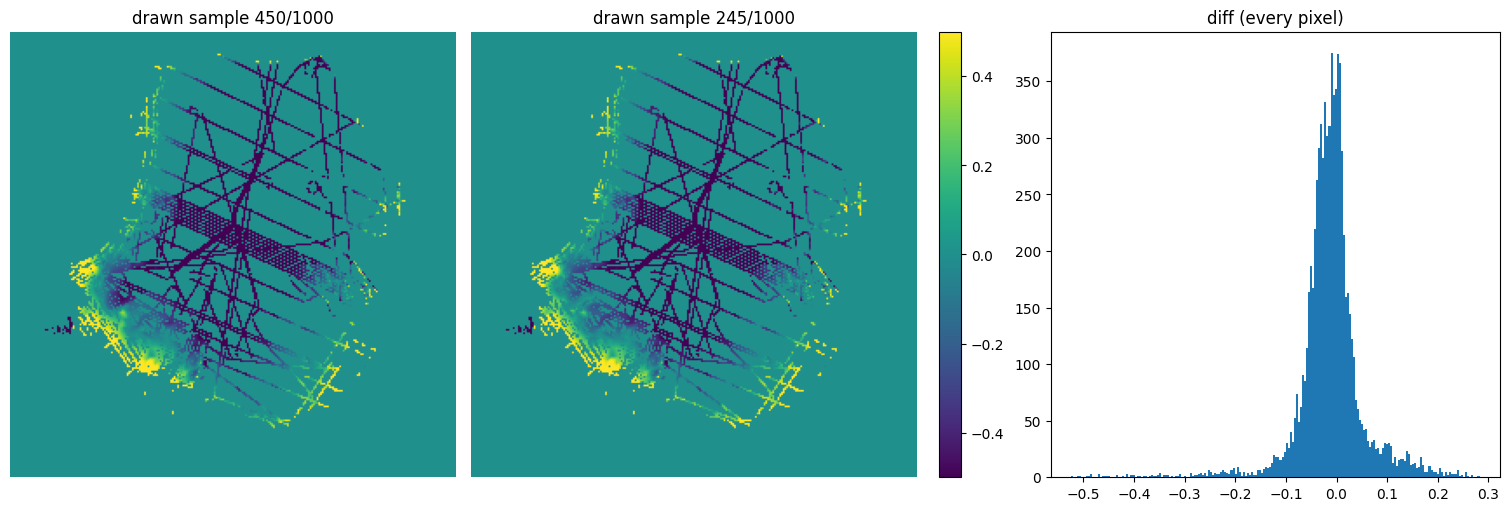

In [496]:
#attenu_pca = joblib.load('../testing/attenu_pca2026-06-12 15:13:52.857122.pkl')

attenu_samples_nf_latent, attenu_samples_log_prob = model_nf_validation.sample(1000)
attenu_samples_nf_latent = attenu_samples_nf_latent.reshape((attenu_samples_nf_latent.shape[0], -1))
attenu_samples_nf_latent = attenu_samples_nf_latent[(~torch.isnan(attenu_samples_log_prob)) & (~torch.isinf(attenu_samples_log_prob)), :]
attenu_samples_nf_latent[attenu_samples_nf_latent == torch.nan] = 0
attenu_samples_nf_latent[attenu_samples_nf_latent == torch.inf] = 0
attenu_samples_nf_latent[attenu_samples_nf_latent == -torch.inf] = 0
attenu_samples_nf_latent[torch.abs(attenu_samples_nf_latent) > 1e2] = 0
attenu_samples_nf = attenu_pca.inverse_transform(attenu_samples_nf_latent.detach().numpy())
attenu_samples_nf = attenu_samples_nf.reshape((attenu_samples_nf_latent.shape[0], 256, 256))

figs, axs = plt.subplots(1,3, figsize = (15, 5), layout="constrained")

vmin = -0.5
vmax = 0.5

rng = np.random.default_rng()
idx = rng.choice(attenu_samples_nf.shape[0], size=2, replace=False)

axs[0].imshow(attenu_samples_nf[idx[0], :, :], vmin = vmin, vmax = vmax)
axs[0].set_title(f"drawn sample {idx[0]}/{attenu_samples_nf.shape[0]}")
axs[0].set_axis_off()

im1 = axs[1].imshow(attenu_samples_nf[idx[1], :, :], vmin = vmin, vmax = vmax)
axs[1].set_title(f"drawn sample {idx[1]}/{attenu_samples_nf.shape[0]}")
axs[1].set_axis_off()
plt.colorbar(im1)

axs[2].hist((attenu_samples_nf[idx[0], :, :] - attenu_samples_nf[idx[1], :, :])[radar_mask].flatten(), bins = 200)
axs[2].set_title("diff (every pixel)")
# axs[2].xaxis.set_visible(False)

Text(0.5, 1.0, 'diff (flattened)')

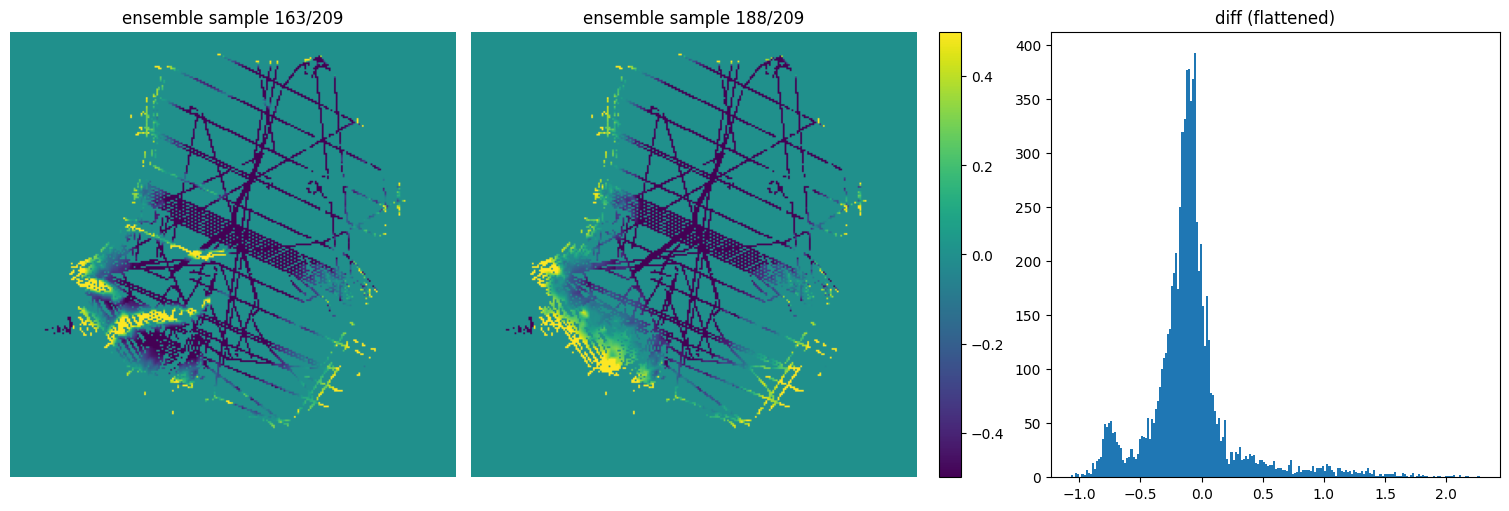

In [497]:
# ensemble samples

attenu_samples_ensemble = attenu_pca.inverse_transform(attenu_latent.detach().numpy().reshape(attenu_latent.shape[0], -1))
attenu_samples_ensemble = attenu_samples_ensemble.reshape((attenu_samples_ensemble.shape[0], 256, 256))
figs, axs = plt.subplots(1,3, figsize = (15, 5), layout="constrained")

vmin = -0.5
vmax = 0.5

rng = np.random.default_rng()
idx = rng.choice(attenu_samples_ensemble.shape[0], size=2, replace=False)

axs[0].imshow(attenu_samples_ensemble[idx[0], :, :], vmin = vmin, vmax = vmax)
axs[0].set_title(f"ensemble sample {idx[0]}/{attenu_samples_ensemble.shape[0]}")
axs[0].set_axis_off()

im1 = axs[1].imshow(attenu_samples_ensemble[idx[1], :, :], vmin = vmin, vmax = vmax)
axs[1].set_title(f"ensemble sample {idx[1]}/{attenu_samples_ensemble.shape[0]}")
axs[1].set_axis_off()
plt.colorbar(im1)

axs[2].hist((attenu_samples_ensemble[idx[0], :, :] - attenu_samples_ensemble[idx[1], :, :])[radar_mask].flatten(), bins = 200)
axs[2].set_title("diff (flattened)")

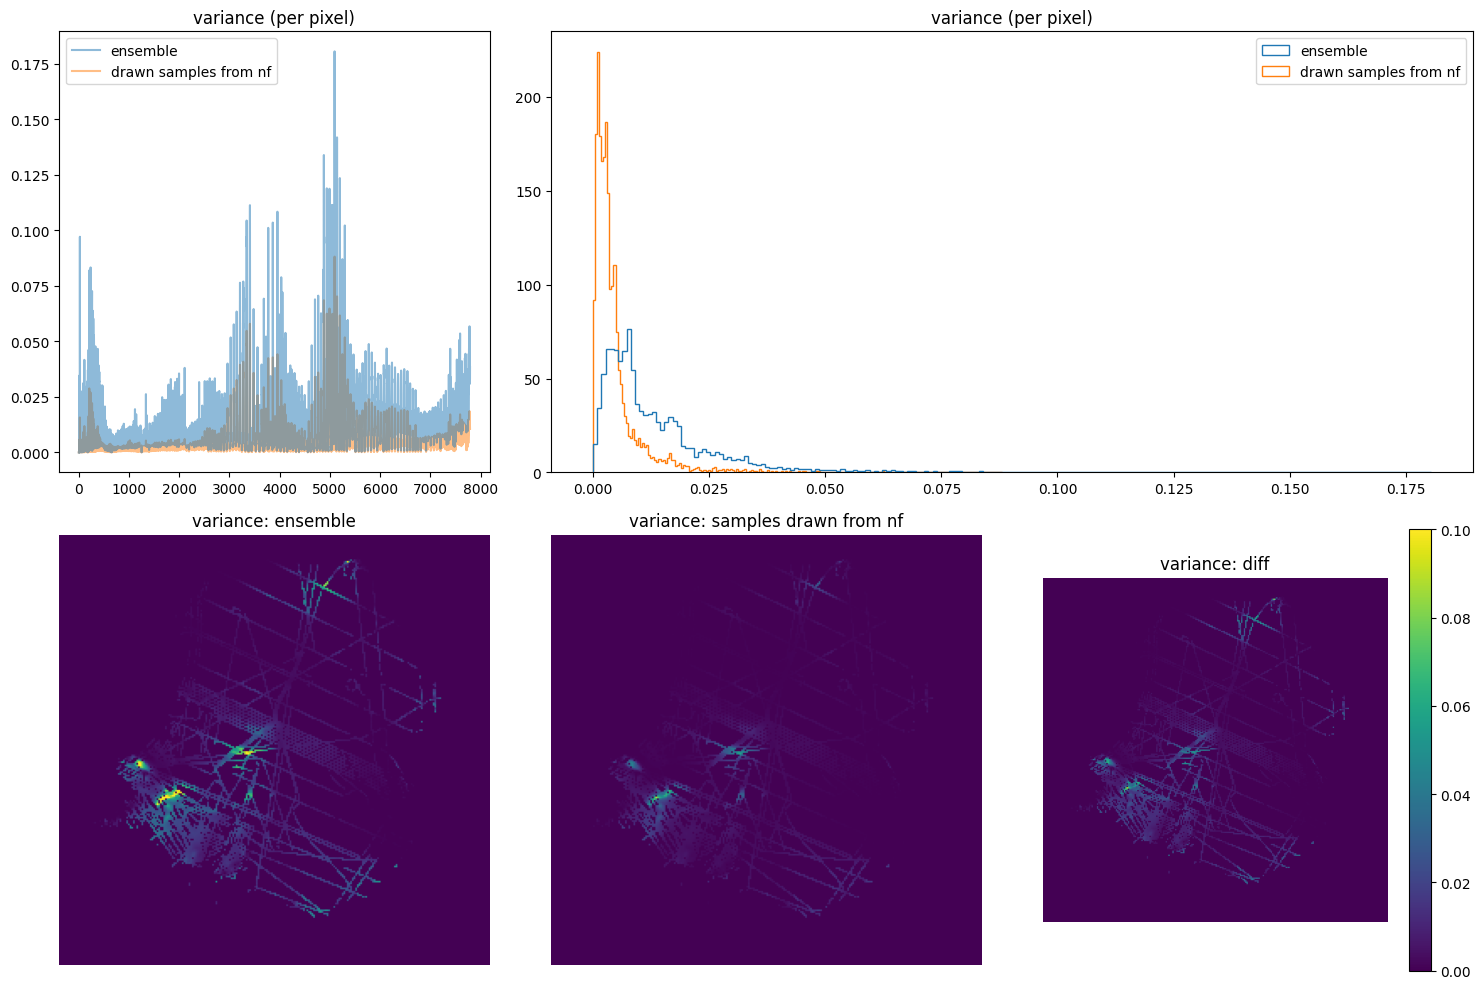

In [498]:
fig, ax = plt.subplot_mosaic([['A', 'B', 'B'],
                              ['C', 'D', 'E']],
                             figsize = (15, 10))

var_attenu_ensemble = np.var(attenu_samples_ensemble, axis = 0)
var_attenu_nf = np.var(attenu_samples_nf, axis = 0)
ax['A'].plot(var_attenu_ensemble[radar_mask].flatten(), label = 'ensemble', alpha = 0.5, zorder = 3)
ax['A'].plot(var_attenu_nf[radar_mask].flatten(), label = 'drawn samples from nf', alpha = 0.5)
ax['A'].set_title("variance (per pixel)")
ax['A'].legend()

bins = np.arange(0, 1, 0.05)
ax['B'].hist(var_attenu_ensemble[radar_mask].flatten(), label = 'ensemble', zorder = 3, bins = 200, density = True, histtype='step')
ax['B'].hist(var_attenu_nf[radar_mask].flatten(), label = 'drawn samples from nf', bins = 200, density = True, histtype='step')
ax['B'].set_title("variance (per pixel)")
ax['B'].legend()

vmin = 0
vmax = 0.1

im0 = ax['C'].imshow(var_attenu_ensemble, vmin = vmin, vmax = vmax)
ax['C'].set_title(f"variance: ensemble")
ax['C'].set_axis_off()

im1 = ax['D'].imshow(var_attenu_nf, vmin = vmin, vmax = vmax)
ax['D'].set_title(f"variance: samples drawn from nf")
ax['D'].set_axis_off()

im2 = ax['E'].imshow(var_attenu_ensemble - var_attenu_nf, vmin = vmin, vmax = vmax)
ax['E'].set_title(f"variance: diff")
ax['E'].set_axis_off()
plt.colorbar(im2)

fig.tight_layout()

/tmp/ipykernel_7521/1648606503.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  log_likelihood = -0.5 * torch.sum(((1/(uniform_std ** 2)) * ((torch.tensor(attenu_obs_standard.flatten()[radar_mask.flatten()]) - torch.tensor(z_image.flatten()[radar_mask.flatten()])) ** 2))) - (n / 2) * np.log(np.sqrt(((2 * np.pi * uniform_std))))


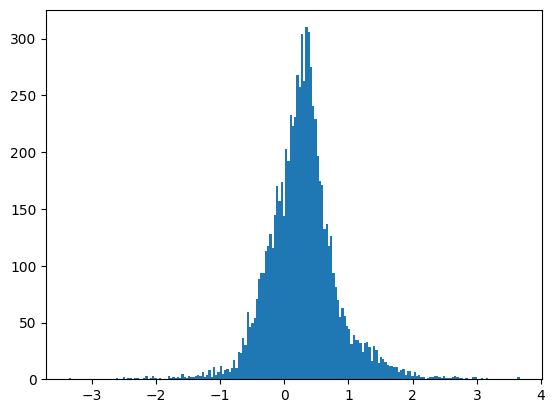

In [499]:
uniform_std = 1

initial_params={"x": model_nf_validation.sample(num_chains)[0].detach()}
x = initial_params["x"]

log_p_prior = model_nf_validation.log_prob(x)
z = model_nf_validation.inverse(x)
z_image = torch.matmul(z, torch.tensor(attenu_pca.components_).float()) + torch.tensor(attenu_pca.mean_)
z_image = z_image.flatten()
n = attenu_obs_standard[radar_mask.flatten()].shape[0]
log_likelihood = -0.5 * torch.sum(((1/(uniform_std ** 2)) * ((torch.tensor(attenu_obs_standard.flatten()[radar_mask.flatten()]) - torch.tensor(z_image.flatten()[radar_mask.flatten()])) ** 2))) - (n / 2) * np.log(np.sqrt(((2 * np.pi * uniform_std))))

plt.hist(attenu_obs_standard[radar_mask.flatten()] - z_image.detach().numpy()[radar_mask.flatten()], label = 'OBS', bins = 200);

In [508]:
import pyro
from pyro.infer.mcmc import MCMC, HMC, NUTS
import hamiltonianMC_nf

std_attenu_obs_samples_standard_relaxed = std_attenu_obs_samples_standard.copy()
# std_attenu_obs_samples_standard_relaxed[std_attenu_obs_samples_standard_relaxed < 0.25] = 0.25
# std_attenu_obs_samples_standard_relaxed = std_attenu_obs_samples_standard * 10

custom_potential = hamiltonianMC_nf.custom_potential(model_nf_validation, attenu_pca,
                                                     attenu_pca.inverse_transform(attenu_latent_test_dataset[0][0].reshape(1, -1)).flatten(),
                                                     std_attenu_obs_samples_standard,
                                                     radar_mask,
                                                     verbose = False)

mcmc_kernel = NUTS(potential_fn = custom_potential.log_posterior)

num_chains = 1
num_samples = 100 # samples per chain

if num_chains == 1:
    mcmc = MCMC(mcmc_kernel, warmup_steps=100, num_samples=num_samples, num_chains = num_chains,
                            initial_params={"x": model_nf_validation.sample(num_chains)[0].detach()}, disable_progbar=False)
elif num_chains > 1:
    mcmc = MCMC(mcmc_kernel, warmup_steps=1000, num_samples=num_samples, num_chains = num_chains,
                            initial_params={"x": model_nf_validation.sample(num_chains)[0].detach().unsqueeze(1)})

mcmc.run(collect_warmup=True)
# .unsqueeze(1)
#
# attenu_samples_hmc_latent[i, :] = mcmc.get_samples()['x'][0][0]

attenu_samples_validation_hmc_latent = mcmc.get_samples()['x']
attenu_samples_validation_hmc_latent = attenu_samples_validation_hmc_latent[:, 0, :]
torch.save(attenu_samples_validation_hmc_latent, './saved_data/attenu_samples_validation_hmc_latent.pt')

Likelihood Gaussian rank = 7791


Sample:  57%|█████▊    | 115/200 [02:17,  2.29s/it, step size=8.74e-04, acc. prob=0.915]

KeyboardInterrupt: 

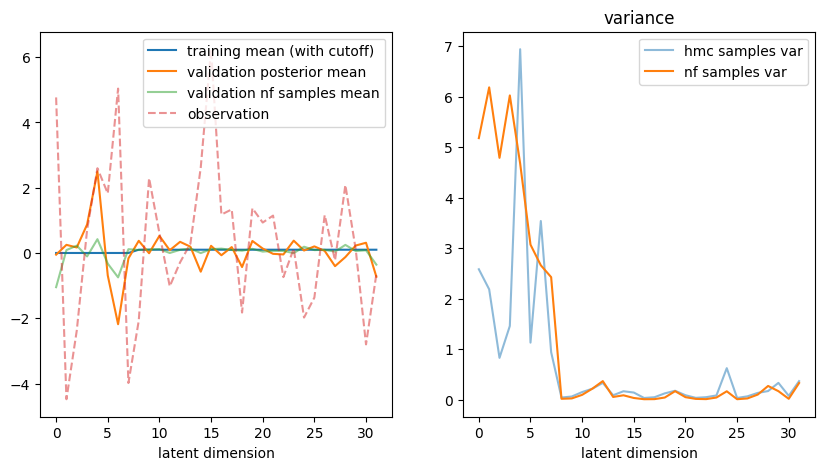

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (10, 5))

#attenu_samples_hmc_latent = np.load("../testing/validation_attenu_samples_hmc_latent_2026-07-07 11:14:29.910122.npz")['attenu_samples_hmc_latent']
attenu_samples_validation_hmc_latent_mean = torch.mean(attenu_samples_validation_hmc_latent, axis = 0)
attenu_latent_cutoff_mean = torch.mean(attenu_latent_cutoff, axis = 0)

ax[0].plot(attenu_latent_cutoff_mean, label = 'training mean (with cutoff)')
ax[0].plot(attenu_samples_validation_hmc_latent_mean, label = 'validation posterior mean')
ax[0].plot(torch.mean(attenu_samples_nf_latent, axis = 0).detach().numpy(), label = 'validation nf samples mean', alpha = 0.5)
ax[0].plot(attenu_latent_test_dataset[0][0], label = 'target', alpha = 0.5, linestyle = 'dashed')

# plt.title('note: training mean at 0 because PCA centers data')

ax[0].set_xlabel('latent dimension')

ax[1].plot(torch.var(attenu_samples_validation_hmc_latent, axis = 0).detach().numpy(), label = 'hmc samples var', alpha = 0.5)
ax[1].plot(torch.var(attenu_samples_nf_latent, axis = 0).detach().numpy(), label = 'nf samples var')
# plt.title('note: training mean at 0 because PCA centers data')
ax[1].set_xlabel('latent dimension')
ax[1].set_title('variance')

ax[0].legend()
ax[1].legend()

# Archive

## Architecture (glow)

In [46]:
# # Define flows
# L = 3
# K = 16
# torch.manual_seed(0)

# input_shape = (1, 8, 8)
# channels = 1
# hidden_channels = 32
# split_mode = 'channel'
# scale = True
# num_classes = 10

# # Set up flows, distributions and merge operations
# q0 = []
# merges = []
# flows = []
# for i in range(L):
#     flows_ = []
#     for j in range(K):
#         flows_ += [nf.flows.GlowBlock(channels * 2 ** (L + 1 - i), hidden_channels,
#                                      split_mode=split_mode, scale=scale)]
#     flows_ += [nf.flows.Squeeze()]
#     flows += [flows_]
#     if i > 0:
#         merges += [nf.flows.Merge()]
#         latent_shape = (input_shape[0] * 2 ** (L - i), input_shape[1] // 2 ** (L - i), 
#                         input_shape[2] // 2 ** (L - i))
#     else:
#         latent_shape = (input_shape[0] * 2 ** (L + 1), input_shape[1] // 2 ** L, 
#                         input_shape[2] // 2 ** L)
    
#     #q0 += [nf.distributions.ClassCondDiagGaussian(latent_shape, num_classes)]
#     print(latent_shape)
#     q0 += [nf.distributions.base.DiagGaussian(latent_shape)]

# # Construct flow model with the multiscale architecture
# model_nf = nf.MultiscaleFlow(q0, flows, merges)